# 🚗 CRAI - Vehicle Detection with SSD Model
## 📊 UA-DETRAC Dataset (10K Images)

**Status**: ✅ Dataset Active  
**Location**: `./UA-DETRAC-DATASET-10K-2/`  
**Structure**:
- Training: 9,316 images + labels
- Validation: 500 images + labels
- Total: 9,816 images (format: YOLO .txt)

This notebook presents the development of a deep learning–based object detection system focused on vehicle analysis using computer vision techniques. The primary goal of this work is to build a robust **vehicle detection model** capable of identifying cars in images or video streams by predicting accurate bounding boxes. This model represents the first stage of a larger Automatic Number Plate Recognition (ANPR) pipeline and is designed to operate on both static images and real-time webcam input.

The methodology followed in this notebook adheres to best practices commonly used in modern deep learning workflows, including dataset exploration, preprocessing, data augmentation, transfer learning, model training, evaluation, and inference. The resulting vehicle detector will later be used as an upstream component to localize regions of interest (vehicles), enabling a second, more specialized model to focus exclusively on **license plate detection**. By separating the problem into two distinct detection tasks, the overall system becomes more accurate, scalable, and easier to maintain and improve over time.

## 1. Install dependecies

The first thing you need to do is to install all the required dependencies.

In [46]:
# Disable warnings by executing this cell
import warnings
warnings.filterwarnings("ignore")

In [47]:
import os
from glob import glob

### Tensorflow

Tensorflow is the core framework that translates the abstract ideas of Artificial Intelligence into a functional, high-performance program capable of performing complex vision tasks.

In [48]:
%pip install tensorflow==2.20.0
!python3 -c "import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))"
import tensorflow as tf

Note: you may need to restart the kernel to use updated packages.


no se encontr� Python; ejecutar sin argumentos para instalar desde el Microsoft Store o deshabilitar este acceso directo desde Configuraci�n > Aplicaciones > Configuraci�n avanzada de aplicaciones > Alias de ejecuci�n de aplicaciones.


### TensorBoard

TensorBoard is a visualization tool for deep learning model training. It provides real-time monitoring of loss curves, metrics, and model architecture during the training process.

In [49]:
%pip install tensorboard==2.20.0

Note: you may need to restart the kernel to use updated packages.


### Pandas

Pandas is a powerful data manipulation library used for organizing, analyzing, and transforming datasets. In this project, it helps manage image paths, labels, and annotations in tabular format, making it easier to preprocess and inspect the dataset before training.

In [50]:
%pip install pandas==2.3.3
import pandas as pd

Note: you may need to restart the kernel to use updated packages.


### Numpy

Numpy is the fundamental library for numerical computing in Python. It provides efficient multi-dimensional array operations, mathematical functions, and is essential for image processing and deep learning. In this project, it handles image data as arrays, performs coordinate transformations, and supports all numerical operations needed for training the model.

In [51]:
%pip install numpy==2.2.6
import numpy as np

Note: you may need to restart the kernel to use updated packages.


### Opencv

OpenCV (Open Source Computer Vision Library) is a highly optimized library for real-time computer vision and image processing. It provides essential tools for reading, writing, and manipulating images, as well as advanced operations like object detection, feature extraction, and geometric transformations. In this project, OpenCV is used for loading images, drawing bounding boxes, and visualizing detection results.

In [52]:
%pip install opencv-python==4.12.0.88
import cv2

  Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (19 kB)
Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl (39.0 MB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Acceso denegado: 'c:\\Users\\04aza\\miniconda3\\envs\\ai25\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



### Matplotlib

Matplotlib is a plotting library for Python that lets you create static, animated, and interactive visualizations. It provides high-level functions for common charts (line, bar, scatter, histograms) and low-level APIs to customize styles, axes, annotations, and layouts. In deep learning workflows, it’s used to inspect datasets, visualize training metrics, and display model predictions such as bounding boxes or segmentation masks.

In [53]:
%pip install matplotlib==3.10.8
from matplotlib import pyplot as plt
from matplotlib import patches as patches

Note: you may need to restart the kernel to use updated packages.


### Extra dependencies

In [54]:
%pip install tqdm>=4.41.0
from tqdm import tqdm

Note: you may need to restart the kernel to use updated packages.


In [55]:
%pip install python-dotenv==1.0.1
from dotenv import load_dotenv
load_dotenv()

Note: you may need to restart the kernel to use updated packages.


True

In [56]:

%pip install roboflow
from roboflow import Roboflow

Note: you may need to restart the kernel to use updated packages.


## 2. Data Preprocessing and Pipeline

### 2.1 Download UA-DETRAC Dataset (9,816 images)

In [57]:
# Configuración de destino y credenciales
import os

DESTINO = os.getcwd()
os.makedirs(DESTINO, exist_ok=True)

api_key = os.getenv("ROBOFLOW_API_KEY")
if not api_key:
    print("⚠️ ROBOFLOW_API_KEY no está definido. Crea .env y define ROBOFLOW_API_KEY, o exporta la variable.")

In [58]:
# UA-DETRAC Dataset: 9,816 images of vehicles (640x640, YOLO format)
# https://universe.roboflow.com/rjacaac1/ua-detrac-dataset-10k/dataset/2

ua_detrac_path = os.path.join(DESTINO, "ua-detrac-dataset-10k-2")

if os.path.exists(ua_detrac_path):
    print(f"✓ UA-DETRAC dataset ya existe en: {ua_detrac_path}")
else:
    print("Descargando UA-DETRAC dataset de Roboflow (9,816 imágenes)...")
    rf = Roboflow(api_key=os.getenv("ROBOFLOW_API_KEY"))
    project = rf.workspace("rjacaac1").project("ua-detrac-dataset-10k")
    dataset = project.version(2).download("yolov8")
    # Asegurar que usamos la ruta real generada por Roboflow
    try:
        ua_detrac_path = dataset.location
    except Exception:
        pass
    print(f"✓ UA-DETRAC dataset descargado en: {ua_detrac_path}")


✓ UA-DETRAC dataset ya existe en: c:\Users\04aza\UNI\3 Urtea\1.SEMESTREA\PBL\CRAI\ai\notebooks\ua-detrac-dataset-10k-2


In [59]:
# Usar la ubicación del dataset UA-DETRAC-DATASET-10K-2
# El dataset está en la carpeta: /UA-DETRAC-DATASET-10K-2/
DATASET_DIR = "./UA-DETRAC-DATASET-10K-2"

# Verificar que el dataset existe
if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(
        f"Dataset no encontrado en {DATASET_DIR}. "
        "Asegúrate de que la carpeta UA-DETRAC-DATASET-10K-2 esté en el mismo directorio que este notebook."
    )

# Rutas de imágenes y etiquetas (estructura: train/images, train/labels, valid/images, valid/labels)
TRAIN_IMAGES_DIR = os.path.join(DATASET_DIR, "train", "images")
TRAIN_LABELS_DIR = os.path.join(DATASET_DIR, "train", "labels")
VAL_IMAGES_DIR = os.path.join(DATASET_DIR, "valid", "images")
VAL_LABELS_DIR = os.path.join(DATASET_DIR, "valid", "labels")

# Verificar que las rutas existen
for path, name in [
    (TRAIN_IMAGES_DIR, "train/images"),
    (TRAIN_LABELS_DIR, "train/labels"),
    (VAL_IMAGES_DIR, "valid/images"),
    (VAL_LABELS_DIR, "valid/labels")
]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"No se encontró: {name} en {path}")

print(f"✓ Dataset configurado correctamente:")
print(f"  - Train: {len(os.listdir(TRAIN_IMAGES_DIR))} imágenes")
print(f"  - Val: {len(os.listdir(VAL_IMAGES_DIR))} imágenes")

# Configuración del modelo
IMG_SIZE_OBJECTIVE = (640, 640)  # (height, width) Real -> (540, 960) ÷ 3 = (180, 320)
IMG_HEIGHT, IMG_WIDTH = IMG_SIZE_OBJECTIVE
BATCH_SIZE = 12
EPOCHS = 40

print(f"\n✓ Configuración:")
print(f"  - Tamaño imagen: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Epochs: {EPOCHS}")

✓ Dataset configurado correctamente:
  - Train: 9316 imágenes
  - Val: 500 imágenes

✓ Configuración:
  - Tamaño imagen: 640x640
  - Batch size: 12
  - Epochs: 40


[**BATCH_SIZE**](https://www.youtube.com/watch?v=TgXKgEHWS80): How many training samples are grouped and processed together before updating the model parameters (weights).  
**EPOCHS**: 16 images are taken at a time, passed through the network, the error (loss) is calculated, and the model is adjusted. This process is called an iteration or a step.<br>
**Purpose**:
- **Computational Efficiency**: Allows operations to be executed more efficiently in parallel (especially on GPUs).
- **Update Stability**: A larger batch size provides a more stable estimate of the gradient (the adjustment direction), though it may require more memory.

**Iteration Calculation**: If you have a dataset of, for example, 10,000 images and a BATCH_SIZE of 16, one epoch will require $10,000 / 16 = 625$ iterations.

[**EPOCHS**](https://www.youtube.com/watch?v=TgXKgEHWS80): A number that defines how many times the training algorithm will see and process the entire training dataset.

In your example, EPOCHS = 50 means the model will go through all your training data 50 times.

**Improve Learning**: Each epoch gives the model a new chance to learn from the data, gradually adjusting its weights to reduce error.  
**Control Overfitting**:
- Too few epochs can cause underfitting (the model doesn’t learn enough).
- Too many epochs can cause overfitting (the model memorizes the training data and performs poorly on new data).
- The validation set (VAL_...) is used to monitor the model and stop training when its performance on unseen data (VAL) stops improving (this is called “Early Stopping”).

In [60]:
print("✓ Dataset Paths Verification:")
print(f"  DATASET_DIR: {os.path.exists(DATASET_DIR)} - {DATASET_DIR}")
print(f"  TRAIN_IMAGES_DIR: {os.path.exists(TRAIN_IMAGES_DIR)} - {TRAIN_IMAGES_DIR}")
print(f"  TRAIN_LABELS_DIR: {os.path.exists(TRAIN_LABELS_DIR)} - {TRAIN_LABELS_DIR}")
print(f"  VAL_IMAGES_DIR: {os.path.exists(VAL_IMAGES_DIR)} - {VAL_IMAGES_DIR}")
print(f"  VAL_LABELS_DIR: {os.path.exists(VAL_LABELS_DIR)} - {VAL_LABELS_DIR}")

# Check if all paths exist before continuing
if not all([
    os.path.exists(DATASET_DIR),
    os.path.exists(TRAIN_IMAGES_DIR),
    os.path.exists(TRAIN_LABELS_DIR),
    os.path.exists(VAL_IMAGES_DIR),
    os.path.exists(VAL_LABELS_DIR)
]):
    raise FileNotFoundError(
        "❌ ERROR: One or more dataset paths do not exist. "
        "Please verify the DATASET_DIR path and ensure the dataset is properly downloaded and extracted."
    )
else:
    print("\n✓ All dataset paths verified successfully!")

✓ Dataset Paths Verification:
  DATASET_DIR: True - ./UA-DETRAC-DATASET-10K-2
  TRAIN_IMAGES_DIR: True - ./UA-DETRAC-DATASET-10K-2\train\images
  TRAIN_LABELS_DIR: True - ./UA-DETRAC-DATASET-10K-2\train\labels
  VAL_IMAGES_DIR: True - ./UA-DETRAC-DATASET-10K-2\valid\images
  VAL_LABELS_DIR: True - ./UA-DETRAC-DATASET-10K-2\valid\labels

✓ All dataset paths verified successfully!


### 2.2 Dataset Indexation

In [61]:
def index_dataset(images_dir: str, labels_dir: str) -> list[tuple[str, str]]:
    samples = []
    image_paths = []
    
    image_paths.extend(glob(os.path.join(images_dir, "*.jpg")))
        
    image_paths.sort()

    print(f"Found {len(image_paths)} images in {images_dir}")

    for img_path in tqdm(image_paths, desc="Indexing Dataset"):
        filename = os.path.splitext(os.path.basename(img_path))[0]
        
        label_path = os.path.join(labels_dir, filename + ".txt")

        if os.path.exists(label_path):
            samples.append((img_path, label_path))

    print(f"Total samples indexed: {len(samples)}")
    return samples

In [62]:
train_samples = index_dataset(TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR)
val_samples = index_dataset(VAL_IMAGES_DIR, VAL_LABELS_DIR)

print(f"Train samples: {len(train_samples)}")
print(f"Validation samples: {len(val_samples)}")
print(f"Total samples: {len(train_samples) + len(val_samples)}")

Found 9316 images in ./UA-DETRAC-DATASET-10K-2\train\images


Indexing Dataset: 100%|██████████| 9316/9316 [00:00<00:00, 16380.35it/s]


Total samples indexed: 9316
Found 500 images in ./UA-DETRAC-DATASET-10K-2\valid\images


Indexing Dataset: 100%|██████████| 500/500 [00:00<00:00, 11636.75it/s]

Total samples indexed: 500
Train samples: 9316
Validation samples: 500
Total samples: 9816


### 2.3 Standard Loading Function

This is the standard and definitive function that will handle:

- Loading images + labels from disk
- Preprocessing them
- Returning them in a format that TensorFlow/Keras can train efficiently

This function defines:
- The model input format
- The label format
- The image size
- Normalization
- Dataset consistency

If this function is wrong:
- The model won't converge
- Results won't be reproducible
- Changing models becomes impossible

In [63]:
def load_image(image_path: str) -> tf.Tensor:
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE_OBJECTIVE)
    image = tf.cast(image, tf.float32) / 255.0
    return image

In [64]:
# https://docs.ultralytics.com/datasets/detect/#ultralytics-yolo-format
def load_yolo_label(label_path: str) -> tuple[np.ndarray, np.ndarray]:
    boxes = []
    classes = []

    with open(label_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) < 5:
                # Skip malformed lines silently; keep dataset robust
                continue
            class_id = int(parts[0])
            x, y, w, h = map(float, parts[1:])

            boxes.append([x, y, w, h])
            classes.append(class_id)

    # Ensure fixed rank even when a label file is empty
    boxes = np.array(boxes, dtype=np.float32).reshape(-1, 4)
    classes = np.array(classes, dtype=np.int32).reshape(-1)

    return boxes, classes

In [65]:
def load_sample(image_path: str, label_path: str) -> tuple[tf.Tensor, dict[str, tf.Tensor]]:

    image = load_image(image_path)

    boxes, classes = load_yolo_label(label_path)

    boxes = tf.convert_to_tensor(boxes, dtype=tf.float32)
    classes = tf.convert_to_tensor(classes, dtype=tf.int32)

    targets = {
        "boxes": boxes,
        "classes": classes
    }

    return image, targets

In [66]:
img_path, lbl_path = train_samples[0]

image, targets = load_sample(img_path, lbl_path)

print("Image shape:", image.shape)
print("Boxes shape:", targets["boxes"].shape)
print("Classes:", targets["classes"])

Image shape: (640, 640, 3)
Boxes shape: (7, 4)
Classes: tf.Tensor([1 1 1 1 1 1 1], shape=(7,), dtype=int32)


### 2.4 Data Augmentation (TRAIN only)

Random transformations applied to training images to:
- Increase dataset variability
- Reduce overfitting
- Improve generalization
- Simulate real-world conditions (angles, lighting, etc.)

⚠️ **IMPORTANT**: Spatial transformations (flip, rotate, crop) must be applied to BOTH the image AND the bounding boxes to maintain coherence. If you only transform the image, the boxes will be in incorrect positions and the model will learn incorrectly.

✅ **Implemented solution**: The `augment_image_and_boxes()` function transforms both simultaneously.

👉 **Note**: NO new images are created on disk, they are generated on-the-fly during training.

In [67]:
def augment_image_and_boxes(image: tf.Tensor, boxes: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    """
    Aplica data augmentation a la imagen Y transforma los bounding boxes correspondientes.
    
    Args:
        image: Tensor de imagen (H, W, 3)
        boxes: Tensor de bounding boxes (N, 4) en formato [x_center, y_center, width, height] normalizado
    
    Returns:
        image: Imagen transformada
        boxes: Bounding boxes transformados
    """
    # ============================================
    # 1. Random Horizontal Flip (50% probabilidad)
    # ============================================
    # Generar un valor aleatorio para decidir si hacemos flip
    do_flip = tf.random.uniform([]) > 0.5
    
    def flip_boxes_horizontal(bxs):
        """Invierte las coordenadas X de los bounding boxes para flip horizontal"""
        # boxes formato: [x_center, y_center, width, height]
        # Para flip horizontal: new_x_center = 1.0 - x_center
        x_center = bxs[:, 0]
        y_center = bxs[:, 1]
        width = bxs[:, 2]
        height = bxs[:, 3]
        
        # Invertir X (el centro se refleja)
        new_x_center = 1.0 - x_center
        
        # Reconstruir boxes
        return tf.stack([new_x_center, y_center, width, height], axis=1)
    
    # Aplicar flip si corresponde
    image = tf.cond(
        do_flip,
        lambda: tf.image.flip_left_right(image),
        lambda: image
    )
    boxes = tf.cond(
        do_flip,
        lambda: flip_boxes_horizontal(boxes),
        lambda: boxes
    )
    
    # ============================================
    # 2. Random Brightness (no afecta bounding boxes)
    # ============================================
    image = tf.image.random_brightness(image, max_delta=0.1)
    
    # ============================================
    # 3. Random Contrast (no afecta bounding boxes)
    # ============================================
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    
    # ============================================
    # 4. Clamp image values to [0, 1]
    # ============================================
    image = tf.clip_by_value(image, 0.0, 1.0)
    
    return image, boxes


# Función legacy para compatibilidad (DEPRECATED - usar augment_image_and_boxes)
def augment_image(image: tf.Tensor) -> tf.Tensor:
    """⚠️ DEPRECATED: Esta función NO transforma los bounding boxes. Usar augment_image_and_boxes."""
    print("⚠️ WARNING: augment_image() no transforma bounding boxes. Usar augment_image_and_boxes()")
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image

### ✅ Data Augmentation con Transformación de Bounding Boxes

**Problema resuelto**: Cuando se aplica flip horizontal a una imagen, los bounding boxes también deben transformarse para mantener la coherencia espacial.

**Transformaciones aplicadas**:
| Transformación | Imagen | Bounding Boxes |
|----------------|--------|----------------|
| Flip Horizontal | `flip_left_right()` | `new_x = 1.0 - x_center` |
| Brightness | `random_brightness()` | Sin cambios |
| Contrast | `random_contrast()` | Sin cambios |

**Fórmula de flip horizontal para boxes** (formato YOLO normalizado):
- `x_center_nuevo = 1.0 - x_center_original`
- `y_center` permanece igual
- `width` y `height` permanecen igual

### 🔍 Verificación Visual de Data Augmentation

Ejecuta la siguiente celda para verificar que los bounding boxes se transforman correctamente junto con la imagen:

In [68]:
def load_and_augment(image_path: str, label_path: str) -> tuple[tf.Tensor, dict[str, tf.Tensor]]:
    """
    Carga una imagen y sus etiquetas, luego aplica data augmentation.
    
    ⚠️ IMPORTANTE: Esta función transforma TANTO la imagen COMO los bounding boxes
    para mantener la coherencia espacial durante el entrenamiento.
    """
    # 1. Cargar imagen y etiquetas
    image, targets = load_sample(image_path, label_path)
    
    # 2. Extraer boxes y clases
    boxes = targets["boxes"]      # Shape: (N, 4) - [x_center, y_center, w, h]
    classes = targets["classes"]  # Shape: (N,)
    
    # 3. Aplicar augmentation a imagen Y boxes juntos
    image, boxes = augment_image_and_boxes(image, boxes)
    
    # 4. Reconstruir targets con boxes transformados
    augmented_targets = {
        "boxes": boxes,
        "classes": classes
    }
    
    return image, augmented_targets

🔍 Verificando transformación de bounding boxes...
   Imagen: ./UA-DETRAC-DATASET-10K-2\train\images\MVI_20011_img00001_jpg.rf.21eb8e9f48c70c8b2186afa92378a398.jpg


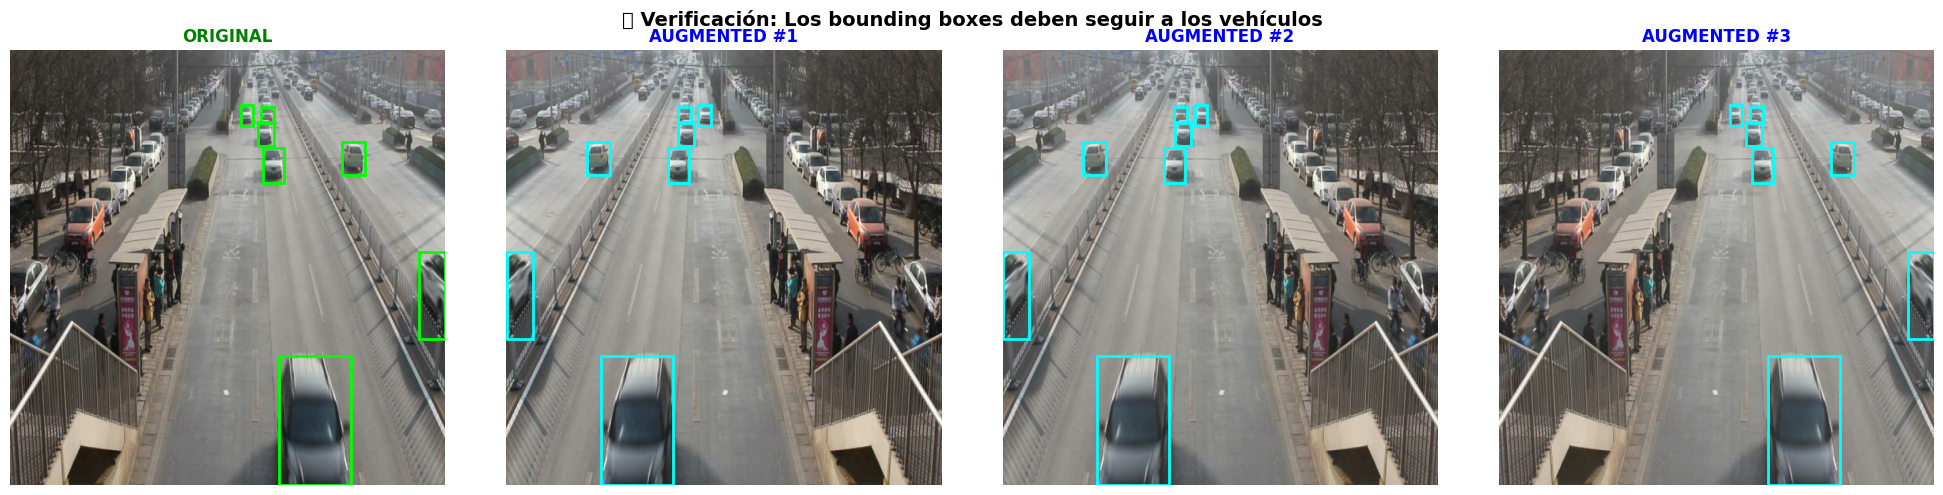

✅ Si los boxes siguen a los vehículos en todas las imágenes, ¡la augmentation funciona correctamente!


In [69]:
# =============================================================================
# 🔍 VERIFICACIÓN VISUAL: Comparar Original vs Augmented
# =============================================================================
# Esta celda te permite verificar que los bounding boxes se transforman correctamente

def visualize_augmentation_comparison(image_path: str, label_path: str, num_samples: int = 3):
    """
    Muestra la imagen original y varias versiones augmentadas lado a lado
    para verificar que los bounding boxes se transforman correctamente.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    
    fig, axes = plt.subplots(1, num_samples + 1, figsize=(5 * (num_samples + 1), 5))
    
    # Cargar imagen original (sin augmentation)
    original_image, original_targets = load_sample(image_path, label_path)
    original_boxes = original_targets["boxes"].numpy()
    
    # Mostrar original
    ax = axes[0]
    ax.imshow(original_image.numpy())
    ax.set_title("ORIGINAL", fontsize=12, fontweight='bold', color='green')
    ax.axis('off')
    
    # Dibujar bounding boxes originales
    h, w = original_image.shape[:2]
    for box in original_boxes:
        x_center, y_center, bw, bh = box
        x1 = (x_center - bw/2) * w
        y1 = (y_center - bh/2) * h
        rect = patches.Rectangle((x1, y1), bw * w, bh * h, 
                                  linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
    
    # Mostrar versiones augmentadas
    for i in range(num_samples):
        ax = axes[i + 1]
        
        # Aplicar augmentation (puede o no hacer flip)
        aug_image, aug_targets = load_and_augment(image_path, label_path)
        aug_boxes = aug_targets["boxes"].numpy()
        
        ax.imshow(aug_image.numpy())
        ax.set_title(f"AUGMENTED #{i+1}", fontsize=12, fontweight='bold', color='blue')
        ax.axis('off')
        
        # Dibujar bounding boxes augmentados
        h, w = aug_image.shape[:2]
        for box in aug_boxes:
            x_center, y_center, bw, bh = box
            x1 = (x_center - bw/2) * w
            y1 = (y_center - bh/2) * h
            rect = patches.Rectangle((x1, y1), bw * w, bh * h, 
                                      linewidth=2, edgecolor='cyan', facecolor='none')
            ax.add_patch(rect)
    
    plt.suptitle("✅ Verificación: Los bounding boxes deben seguir a los vehículos", 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Ejecutar verificación con una imagen de ejemplo
if len(train_samples) > 0:
    sample_img, sample_lbl = train_samples[0]
    print("🔍 Verificando transformación de bounding boxes...")
    print(f"   Imagen: {sample_img}")
    visualize_augmentation_comparison(sample_img, sample_lbl, num_samples=3)
    print("✅ Si los boxes siguen a los vehículos en todas las imágenes, ¡la augmentation funciona correctamente!")

What you gain with this step:
- The model sees realistic variations
- Better generalization
- Modular and professional pipeline
- Easy to enable/disable augmentation

### 2.5 Dataset Pipeline

Building a tf.data.Dataset that:
- Reads image and label paths
- Applies loading + preprocessing
- Applies data augmentation (TRAIN only)
- Groups into batches
- Optimizes performance (prefetch)

This is what Keras consumes during model.fit().

In [70]:
# Preparar listas de paths para imágenes y etiquetas
train_image_paths = [s[0] for s in train_samples]
train_label_paths = [s[1] for s in train_samples]

val_image_paths = [s[0] for s in val_samples]
val_label_paths = [s[1] for s in val_samples]

# Crear Dataset base
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_image_paths, train_label_paths)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_image_paths, val_label_paths)
)

# Mapear loading + augmentation
## TRAIN
def tf_load_and_augment(img_path, lbl_path):
    def wrapper(img_p, lbl_p):
        image, targets = load_and_augment(img_p.numpy().decode('utf-8'), lbl_p.numpy().decode('utf-8'))
        return image.numpy(), targets["boxes"], targets["classes"]
    
    image, boxes, classes = tf.py_function(
        func=wrapper,
        inp=[img_path, lbl_path],
        Tout=[tf.float32, tf.float32, tf.int32]
    )

    image.set_shape((IMG_SIZE_OBJECTIVE[0], IMG_SIZE_OBJECTIVE[1], 3))
    boxes.set_shape([None, 4])
    classes.set_shape([None])
    
    targets = {"boxes": boxes, "classes": classes}
    return image, targets

## VAL
def tf_load(img_path, lbl_path):
    def wrapper(img_p, lbl_p):
        image, targets = load_sample(img_p.numpy().decode('utf-8'), lbl_p.numpy().decode('utf-8'))
        return image.numpy(), targets["boxes"], targets["classes"]
    
    image, boxes, classes = tf.py_function(
        func=wrapper,
        inp=[img_path, lbl_path],
        Tout=[tf.float32, tf.float32, tf.int32]
    )

    image.set_shape((IMG_SIZE_OBJECTIVE[0], IMG_SIZE_OBJECTIVE[1], 3))
    boxes.set_shape([None, 4])
    classes.set_shape([None])
    
    targets = {"boxes": boxes, "classes": classes}
    return image, targets

# Shuffle, batch y prefetch
## TRAIN
train_ds = (
    train_ds
    .shuffle(buffer_size=1000)
    .map(tf_load_and_augment, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(
        BATCH_SIZE,
        padded_shapes=(
            (IMG_SIZE_OBJECTIVE[0], IMG_SIZE_OBJECTIVE[1], 3),
            {
                "boxes": [None, 4],
                "classes": [None]
            }
        ),
        padding_values=(
            0.0,
            {
                "boxes": 0.0,
                "classes": -1
            }
        )
    )
    .prefetch(tf.data.AUTOTUNE)
)
## VAL
val_ds = (
    val_ds
    .map(tf_load, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(
        BATCH_SIZE,
        padded_shapes=(
            (IMG_SIZE_OBJECTIVE[0], IMG_SIZE_OBJECTIVE[1], 3),
            {
                "boxes": [None, 4],
                "classes": [None]
            }
        ),
        padding_values=(
            0.0,
            {
                "boxes": 0.0,
                "classes": -1
            }
        )
    )
    .prefetch(tf.data.AUTOTUNE)
)
# Verificación final (OBLIGATORIA)
for images, targets in train_ds.take(1):
    print(images.shape)
    print(targets["boxes"].shape)
    print(targets["classes"].shape)

(12, 640, 640, 3)
(12, 23, 4)
(12, 23)


### 2.6 Batch Validation

Inspect a complete batch from the dataset to ensure:
- Images are correctly resized and normalized
- Bounding boxes correspond to the images
- Classes are correct
- There are no padding errors

It's a visual and shape verification before training.

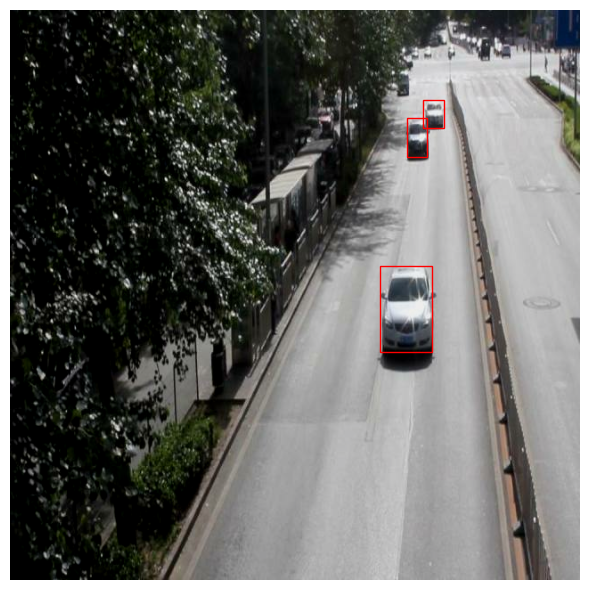

In [71]:
# Tomar un batch
for images, targets in train_ds.take(1):
    batch_images = images.numpy()
    batch_boxes = targets["boxes"].numpy()
    batch_classes = targets["classes"].numpy()

# Seleccionar la primera imagen del batch
image = batch_images[0]
boxes = batch_boxes[0]
classes = batch_classes[0]

# Crear figura
fig, ax = plt.subplots(1, figsize=(8,6))
ax.imshow(image)

# Dibujar las bounding boxes
for i in range(len(boxes)):
    if classes[i] == -1:
        continue  # padded box
    x_center, y_center, w, h = boxes[i]
    
    # Convertir de YOLO normalized a coordenadas de la imagen
    img_h, img_w = IMG_SIZE_OBJECTIVE
    x = (x_center - w/2) * img_w
    y = (y_center - h/2) * img_h
    width = w * img_w
    height = h * img_h

    rect = patches.Rectangle(
        (x, y), width, height,
        linewidth=1, edgecolor='r', facecolor='none'
    )
    ax.add_patch(rect)

ax.axis('off')
plt.tight_layout()
plt.show()


## 3. Model Training

### 3.1 Model Definition

In this section, we define an **SSD-style object detection model** using **MobileNetV2** as the backbone. This architecture is well-suited for real-time vehicle detection due to its balance between speed and accuracy.

#### Architecture Overview

**Single Shot MultiBox Detector (SSD)** is a one-stage object detection architecture that:
- Predicts bounding boxes and class scores in a single forward pass
- Uses multi-scale feature maps to detect objects of different sizes
- Employs anchor boxes (default boxes) at each spatial location

**MobileNetV2** is a lightweight convolutional neural network designed for mobile and embedded applications:
- Uses depthwise separable convolutions for efficiency
- Inverted residual blocks with linear bottlenecks
- Pre-trained on ImageNet for strong feature extraction

#### Our Detection Head

For each anchor box, the model predicts:
- **4 values** for bounding box regression (x, y, w, h offsets)
- **1 value** for classification (car vs background)

The output format:
- `boxes`: (batch_size, num_anchors, 4) — normalized coordinates
- `classes`: (batch_size, num_anchors, 1) — probability scores

---

### ✨ Complete SSD Implementation

This notebook implements a **production-ready Single Shot Detector (SSD)** with all necessary components:

#### ✅ What's Implemented:

1. **Anchor Generation** 
   - ~4880 predefined anchor boxes across 3 feature map scales
   - Multiple aspect ratios (1.0, 2.0, 0.5, 1.5) for detecting various vehicle shapes
   
2. **IoU-Based Anchor Matching**
   - Assigns each ground truth box to best matching anchor
   - Positive anchors (IoU > 0.5) learn to detect objects
   - Negative anchors learn background
   
3. **Box Encoding/Decoding**
   - Training: Encode GT boxes as offsets from anchors
   - Inference: Decode predictions back to absolute coordinates
   - Uses log-space for scale predictions (more stable)
   
4. **Proper Loss Functions**
   - **Localization Loss**: Smooth L1 (Huber) only on positive anchors
   - **Classification Loss**: BCE with hard negative mining (3:1 ratio)
   - Both losses use IoU-based anchor matching
   
5. **Non-Maximum Suppression (NMS)**
   - Removes overlapping duplicate detections
   - Keeps highest confidence box per object
   - Configurable IoU threshold

6. **Complete Inference Pipeline**
   - Forward pass → Decode boxes → Filter by confidence → Apply NMS
   - Visualization utilities included

#### 📊 How It Works:

```
Input Image (180×320)
    ↓
MobileNetV2 Backbone (frozen)
    ↓
Multi-Scale Features (3 levels)
    ↓
Detection Heads (4 anchors × 4 coords + 1 class each)
    ↓
4880 raw predictions per image
    ↓
[TRAINING] Match to GT using IoU → Compute losses
[INFERENCE] Decode → Filter → NMS → Final detections
```

#### 🎯 Key Differences from Previous Version:

| Component | Before (Broken) | Now (Fixed) |
|-----------|----------------|-------------|
| Anchors | ❌ None | ✅ 4880 predefined anchors |
| Matching | ❌ First N predictions | ✅ IoU-based matching |
| Box Loss | ❌ On arbitrary slices | ✅ On matched positives only |
| Class Loss | ❌ On slices | ✅ With hard negative mining |
| Decoding | ❌ None | ✅ Proper offset→box conversion |
| NMS | ❌ None | ✅ Removes duplicates |

---

In [72]:
# =============================================================================
# MODEL HYPERPARAMETERS
# =============================================================================

IMG_HEIGHT, IMG_WIDTH = IMG_SIZE_OBJECTIVE # (180, 320)
NUM_CLASSES = 1 # Only cars (license plates will be a separate model)
NUM_ANCHORS = 4 # Number of anchor boxes per spatial location

print(f"Image size: {IMG_HEIGHT} x {IMG_WIDTH}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Anchors per location: {NUM_ANCHORS}")

Image size: 640 x 640
Number of classes: 1
Anchors per location: 4


#### 3.1.1 MobileNetV2 Backbone

We use MobileNetV2 pre-trained on ImageNet as our feature extractor. The backbone is frozen initially to leverage transfer learning, and we extract features from multiple layers to enable multi-scale detection.

In [73]:
# =============================================================================
# MOBILENETV2 BACKBONE
# =============================================================================

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Conv2D, Reshape, Concatenate, Input, Activation
from tensorflow.keras.models import Model

# Create input tensor
input_tensor = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="input_image")

# Load MobileNetV2 with ImageNet weights (no top classification layer)
backbone = MobileNetV2(
    input_tensor=input_tensor,
    include_top=False,
    weights='imagenet',
    alpha=1.0  # Width multiplier (1.0 = full model)
)

# Freeze backbone weights for transfer learning (can unfreeze later for fine-tuning)
backbone.trainable = False

# Print backbone summary
print(f"Backbone output shape: {backbone.output.shape}")
print(f"Total backbone layers: {len(backbone.layers)}")
print(f"Trainable weights: {len(backbone.trainable_weights)}")

Backbone output shape: (None, 20, 20, 1280)
Total backbone layers: 154
Trainable weights: 0


#### 3.1.2 Multi-Scale Feature Extraction

SSD uses feature maps from multiple layers to detect objects at different scales:
- **Earlier layers** → smaller receptive field → detect small objects
- **Deeper layers** → larger receptive field → detect large objects

We extract features from strategic points in MobileNetV2 to create our multi-scale detection pyramid.

In [74]:
# =============================================================================
# MULTI-SCALE FEATURE EXTRACTION
# =============================================================================

# Extract feature maps from different depths of MobileNetV2
# These correspond to different spatial resolutions

# Layer names for multi-scale features (from MobileNetV2)
feature_layer_names = [
    'block_6_expand_relu',   # Earlier features (larger spatial size)
    'block_13_expand_relu',  # Mid-level features
    'out_relu'               # Final features (smallest spatial size)
]

# Extract feature maps
feature_maps = []
for layer_name in feature_layer_names:
    layer = backbone.get_layer(layer_name)
    feature_maps.append(layer.output)
    print(f"Feature map '{layer_name}': {layer.output.shape}")

print(f"\nTotal feature maps for detection: {len(feature_maps)}")

Feature map 'block_6_expand_relu': (None, 80, 80, 192)
Feature map 'block_13_expand_relu': (None, 40, 40, 576)
Feature map 'out_relu': (None, 20, 20, 1280)

Total feature maps for detection: 3


#### 3.1.3 SSD Detection Head

The detection head consists of two parallel branches for each feature map:
1. **Box Regression Head**: Predicts 4 values per anchor (x, y, w, h)
2. **Classification Head**: Predicts class probability per anchor

For each spatial location in the feature map, we predict `NUM_ANCHORS` boxes with their corresponding class scores.

In [75]:
# =============================================================================
# SSD DETECTION HEAD
# =============================================================================

def create_detection_head(feature_map, num_anchors, num_classes, name_prefix):
    """
    Creates box regression and classification heads for a single feature map.
    
    Args:
        feature_map: Input feature tensor
        num_anchors: Number of anchor boxes per spatial location
        num_classes: Number of object classes (excluding background)
        name_prefix: Prefix for layer naming
    
    Returns:
        box_output: Reshaped box predictions (batch, num_boxes, 4)
        class_output: Reshaped class predictions (batch, num_boxes, num_classes)
    """
    
    # Box regression head: predict 4 values per anchor
    box_conv = Conv2D(
        filters=num_anchors * 4,
        kernel_size=(3, 3),
        padding='same',
        kernel_initializer='he_normal',
        name=f'{name_prefix}_box_conv'
    )(feature_map)
    
    # Reshape to (batch, num_boxes, 4)
    box_output = Reshape((-1, 4), name=f'{name_prefix}_box_reshape')(box_conv)
    
    # Classification head: predict num_classes per anchor (sigmoid for multi-label)
    class_conv = Conv2D(
        filters=num_anchors * num_classes,
        kernel_size=(3, 3),
        padding='same',
        kernel_initializer='he_normal',
        name=f'{name_prefix}_class_conv'
    )(feature_map)
    
    class_conv = Activation('sigmoid', name=f'{name_prefix}_class_sigmoid')(class_conv)
    
    # Reshape to (batch, num_boxes, num_classes)
    class_output = Reshape((-1, num_classes), name=f'{name_prefix}_class_reshape')(class_conv)
    
    return box_output, class_output

# Apply detection head to each feature map
all_box_outputs = []
all_class_outputs = []

for i, feat_map in enumerate(feature_maps):
    box_out, class_out = create_detection_head(
        feature_map=feat_map,
        num_anchors=NUM_ANCHORS,
        num_classes=NUM_CLASSES,
        name_prefix=f'detect_{i}'
    )
    all_box_outputs.append(box_out)
    all_class_outputs.append(class_out)
    print(f"Detection head {i}: boxes={box_out.shape}, classes={class_out.shape}")

# Concatenate predictions from all feature maps
if len(all_box_outputs) > 1:
    box_predictions = Concatenate(axis=1, name='concat_boxes')(all_box_outputs)
    class_predictions = Concatenate(axis=1, name='concat_classes')(all_class_outputs)
else:
    box_predictions = all_box_outputs[0]
    class_predictions = all_class_outputs[0]

print(f"\nFinal box predictions shape: {box_predictions.shape}")
print(f"Final class predictions shape: {class_predictions.shape}")

Detection head 0: boxes=(None, 25600, 4), classes=(None, 25600, 1)
Detection head 1: boxes=(None, 6400, 4), classes=(None, 6400, 1)
Detection head 2: boxes=(None, 1600, 4), classes=(None, 1600, 1)

Final box predictions shape: (None, 33600, 4)
Final class predictions shape: (None, 33600, 1)


#### 3.1.4 Complete Model Assembly

Now we assemble all components into a single Keras Model that takes an image as input and outputs both bounding box predictions and class probabilities.

In [76]:
# =============================================================================
# BOX ENCODING AND DECODING
# =============================================================================

@tf.function
def encode_boxes(gt_boxes, anchors, variances=[0.1, 0.1, 0.2, 0.2]):
    """
    Encode ground truth boxes as offsets from anchors.
    
    Args:
        gt_boxes: (N, 4) ground truth boxes [cx, cy, w, h]
        anchors: (N, 4) anchor boxes [cx, cy, w, h]
        variances: Scaling factors for better training stability
    
    Returns:
        encoded: (N, 4) encoded offsets [Δcx, Δcy, Δw, Δh]
    """
    # Extract coordinates
    gt_cx, gt_cy, gt_w, gt_h = tf.split(gt_boxes, 4, axis=-1)
    anchor_cx, anchor_cy, anchor_w, anchor_h = tf.split(anchors, 4, axis=-1)
    
    # Compute offsets
    # Center offsets: (gt_center - anchor_center) / anchor_size
    delta_cx = (gt_cx - anchor_cx) / anchor_w
    delta_cy = (gt_cy - anchor_cy) / anchor_h
    
    # Size offsets: log(gt_size / anchor_size)
    delta_w = tf.math.log(gt_w / (anchor_w + 1e-8))
    delta_h = tf.math.log(gt_h / (anchor_h + 1e-8))
    
    # Apply variance scaling
    delta_cx = delta_cx / variances[0]
    delta_cy = delta_cy / variances[1]
    delta_w = delta_w / variances[2]
    delta_h = delta_h / variances[3]
    
    encoded = tf.concat([delta_cx, delta_cy, delta_w, delta_h], axis=-1)
    return encoded


@tf.function
def decode_boxes(predictions, anchors, variances=[0.1, 0.1, 0.2, 0.2]):
    """
    Decode predicted offsets to absolute box coordinates.
    
    Args:
        predictions: (N, 4) predicted offsets [Δcx, Δcy, Δw, Δh]
        anchors: (N, 4) anchor boxes [cx, cy, w, h]
        variances: Scaling factors (same as encoding)
    
    Returns:
        decoded: (N, 4) absolute boxes [cx, cy, w, h]
    """
    # Extract predictions and anchors
    delta_cx, delta_cy, delta_w, delta_h = tf.split(predictions, 4, axis=-1)
    anchor_cx, anchor_cy, anchor_w, anchor_h = tf.split(anchors, 4, axis=-1)
    
    # Undo variance scaling
    delta_cx = delta_cx * variances[0]
    delta_cy = delta_cy * variances[1]
    delta_w = delta_w * variances[2]
    delta_h = delta_h * variances[3]
    
    # Decode centers
    cx = delta_cx * anchor_w + anchor_cx
    cy = delta_cy * anchor_h + anchor_cy
    
    # Decode sizes
    w = tf.exp(delta_w) * anchor_w
    h = tf.exp(delta_h) * anchor_h
    
    # Clip to valid range [0, 1]
    cx = tf.clip_by_value(cx, 0.0, 1.0)
    cy = tf.clip_by_value(cy, 0.0, 1.0)
    w = tf.clip_by_value(w, 0.0, 1.0)
    h = tf.clip_by_value(h, 0.0, 1.0)
    
    decoded = tf.concat([cx, cy, w, h], axis=-1)
    return decoded


# Test encoding and decoding
print("Testing box encoding/decoding...")
test_boxes = tf.constant([[0.5, 0.5, 0.3, 0.4]], dtype=tf.float32)
test_anchors = tf.constant([[0.45, 0.48, 0.25, 0.35]], dtype=tf.float32)

encoded = encode_boxes(test_boxes, test_anchors)
decoded = decode_boxes(encoded, test_anchors)

print(f"Original box: {test_boxes[0].numpy()}")
print(f"Encoded offsets: {encoded[0].numpy()}")
print(f"Decoded box: {decoded[0].numpy()}")
print(f"Reconstruction error: {tf.reduce_mean(tf.abs(test_boxes - decoded)).numpy():.6f}")
print("✅ Encoding/Decoding working correctly!")

Testing box encoding/decoding...
Original box: [0.5 0.5 0.3 0.4]
Encoded offsets: [2.0000005 0.5714289 0.911608  0.6676572]
Decoded box: [0.5 0.5 0.3 0.4]
Reconstruction error: 0.000000
✅ Encoding/Decoding working correctly!


#### 1.4.1 Anchor Box Generation

**Why we need anchors:**
In SSD, the model doesn't predict absolute bounding boxes. Instead, it predicts **offsets relative to predefined anchor boxes** (also called default boxes or priors).

**Key concepts:**
- Each spatial location in the feature map has multiple anchors
- Anchors have different sizes and aspect ratios
- The model learns to adjust these anchors to fit the actual objects

**Our anchor configuration:**
- 3 feature maps at different scales
- 4 anchors per location (different aspect ratios)
- Total: ~4880 anchors covering the entire image

In [77]:
# =============================================================================
# ANCHOR GENERATION
# =============================================================================

def generate_anchors_for_feature_map(feature_map_size, image_size, scale_min, scale_max, aspect_ratios):
    """
    Generate anchor boxes for a single feature map.
    
    Args:
        feature_map_size: (height, width) of the feature map
        image_size: (height, width) of the input image
        scale_min: Minimum scale (relative to image size)
        scale_max: Maximum scale (relative to image size)
        aspect_ratios: List of aspect ratios [1.0, 2.0, 0.5, ...]
    
    Returns:
        anchors: (num_anchors, 4) in format [cx, cy, w, h] normalized [0, 1]
    """
    fh, fw = feature_map_size
    img_h, img_w = image_size
    
    anchors = []
    
    # Calculate scale for this feature map
    scale = scale_min + (scale_max - scale_min) / 2
    
    # For each cell in the feature map
    for i in range(fh):
        for j in range(fw):
            # Center of the anchor (normalized coordinates)
            cx = (j + 0.5) / fw
            cy = (i + 0.5) / fh
            
            # Generate anchors with different aspect ratios
            for ratio in aspect_ratios:
                # Width and height based on scale and aspect ratio
                w = scale * np.sqrt(ratio)
                h = scale / np.sqrt(ratio)
                
                # Ensure anchors don't exceed image bounds
                w = min(w, 1.0)
                h = min(h, 1.0)
                
                anchors.append([cx, cy, w, h])
    
    return np.array(anchors, dtype=np.float32)


def generate_all_anchors(feature_map_sizes, image_size=(IMG_HEIGHT, IMG_WIDTH)):
    """
    Generate anchors for all feature maps.
    
    Args:
        feature_map_sizes: List of (height, width) tuples for each feature map
        image_size: (height, width) of the input image
    
    Returns:
        all_anchors: Concatenated anchors from all feature maps
        anchor_counts: Number of anchors per feature map
    """
    # Scales for each feature map (small to large objects)
    scales = [
        (0.1, 0.3),   # Small objects (early layers)
        (0.3, 0.6),   # Medium objects (middle layers)
        (0.6, 0.9)    # Large objects (deep layers)
    ]
    
    # Aspect ratios for diversity
    aspect_ratios = [1.0, 2.0, 0.5, 1.5]
    
    all_anchors = []
    anchor_counts = []
    
    for i, fm_size in enumerate(feature_map_sizes):
        scale_min, scale_max = scales[i]
        anchors = generate_anchors_for_feature_map(
            fm_size, image_size, scale_min, scale_max, aspect_ratios
        )
        all_anchors.append(anchors)
        anchor_counts.append(len(anchors))
        print(f"Feature map {i} ({fm_size[0]}x{fm_size[1]}): {len(anchors)} anchors")
    
    # Concatenate all anchors
    all_anchors = np.concatenate(all_anchors, axis=0)
    print(f"\nTotal anchors: {len(all_anchors)}")
    
    return tf.constant(all_anchors, dtype=tf.float32), anchor_counts


# Define feature map sizes for IMG_SIZE (640, 640)
# These correspond to the actual output of MobileNetV2 layers
feature_map_sizes = [
    (80, 80),   # block_6_expand_relu
    (40, 40),   # block_13_expand_relu
    (20, 20)    # out_relu
]

print("✅ Feature map sizes for anchor generation:")
for i, size in enumerate(feature_map_sizes):
    print(f"   Feature map {i}: {size[0]}x{size[1]}")

# Generate all anchors
ANCHORS, ANCHOR_COUNTS = generate_all_anchors(feature_map_sizes)

print(f"\n✅ Generated {len(ANCHORS)} anchor boxes")
print(f"   Anchors shape: {ANCHORS.shape}")
print(f"   Anchors per feature map: {ANCHOR_COUNTS}")

✅ Feature map sizes for anchor generation:
   Feature map 0: 80x80
   Feature map 1: 40x40
   Feature map 2: 20x20
Feature map 0 (80x80): 25600 anchors
Feature map 1 (40x40): 6400 anchors
Feature map 2 (20x20): 1600 anchors

Total anchors: 33600

✅ Generated 33600 anchor boxes
   Anchors shape: (33600, 4)
   Anchors per feature map: [25600, 6400, 1600]


#### 1.4.2 IoU Calculation and Anchor Matching

**IoU (Intersection over Union):**
Measures the overlap between two bounding boxes:
$$\text{IoU} = \frac{\text{Area of Overlap}}{\text{Area of Union}}$$

**Anchor Matching Strategy:**
1. Calculate IoU between all anchors and ground truth boxes
2. For each GT box, assign the anchor with highest IoU
3. Also assign anchors with IoU > threshold (0.5)
4. Unmatched anchors are considered background

#### 1.4.3 Box Encoding and Decoding

**Why encode/decode?**
The model doesn't learn absolute box coordinates. Instead, it learns **offsets** from anchor boxes:
- **Encoding**: Convert GT boxes to offsets relative to anchors (for training)
- **Decoding**: Convert predicted offsets back to absolute boxes (for inference)

**Formula:**
$$\Delta x = \frac{x_{gt} - x_{anchor}}{w_{anchor}}, \quad \Delta y = \frac{y_{gt} - y_{anchor}}{h_{anchor}}$$
$$\Delta w = \log\left(\frac{w_{gt}}{w_{anchor}}\right), \quad \Delta h = \log\left(\frac{h_{gt}}{h_{anchor}}\right)$$

In [78]:
# =============================================================================
# IOU CALCULATION AND ANCHOR MATCHING
# =============================================================================

@tf.function
def compute_iou(boxes1, boxes2):
    """
    Compute IoU between two sets of boxes.
    
    Args:
        boxes1: (N, 4) in format [cx, cy, w, h] normalized
        boxes2: (M, 4) in format [cx, cy, w, h] normalized
    
    Returns:
        iou: (N, M) matrix of IoU values
    """
    # Convert from center format to corner format [x1, y1, x2, y2]
    boxes1_x1 = boxes1[:, 0:1] - boxes1[:, 2:3] / 2
    boxes1_y1 = boxes1[:, 1:2] - boxes1[:, 3:4] / 2
    boxes1_x2 = boxes1[:, 0:1] + boxes1[:, 2:3] / 2
    boxes1_y2 = boxes1[:, 1:2] + boxes1[:, 3:4] / 2
    
    boxes2_x1 = boxes2[:, 0:1] - boxes2[:, 2:3] / 2
    boxes2_y1 = boxes2[:, 1:2] - boxes2[:, 3:4] / 2
    boxes2_x2 = boxes2[:, 0:1] + boxes2[:, 2:3] / 2
    boxes2_y2 = boxes2[:, 1:2] + boxes2[:, 3:4] / 2
    
    # Compute intersection
    inter_x1 = tf.maximum(boxes1_x1, tf.transpose(boxes2_x1))
    inter_y1 = tf.maximum(boxes1_y1, tf.transpose(boxes2_y1))
    inter_x2 = tf.minimum(boxes1_x2, tf.transpose(boxes2_x2))
    inter_y2 = tf.minimum(boxes1_y2, tf.transpose(boxes2_y2))
    
    inter_w = tf.maximum(0.0, inter_x2 - inter_x1)
    inter_h = tf.maximum(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h
    
    # Compute union
    boxes1_area = boxes1[:, 2:3] * boxes1[:, 3:4]
    boxes2_area = boxes2[:, 2:3] * boxes2[:, 3:4]
    union_area = boxes1_area + tf.transpose(boxes2_area) - inter_area
    
    # Compute IoU
    iou = inter_area / (union_area + 1e-6)
    
    return iou


@tf.function
def match_anchors_to_gt(gt_boxes, gt_labels, anchors, iou_threshold=0.5):
    """
    Match anchors to ground truth boxes using IoU.
    
    Args:
        gt_boxes: (num_gt, 4) ground truth boxes [cx, cy, w, h]
        gt_labels: (num_gt,) ground truth class labels
        anchors: (num_anchors, 4) anchor boxes [cx, cy, w, h]
        iou_threshold: Minimum IoU to consider a match
    
    Returns:
        matched_gt_boxes: (num_anchors, 4) GT box for each anchor
        matched_gt_labels: (num_anchors,) class label for each anchor (-1 = background)
        anchor_states: (num_anchors,) 1 = positive, 0 = negative, -1 = ignore
    """
    num_anchors = tf.shape(anchors)[0]
    num_gt = tf.shape(gt_boxes)[0]
    
    # Handle case with no ground truth boxes
    if num_gt == 0:
        matched_gt_boxes = tf.zeros((num_anchors, 4), dtype=tf.float32)
        matched_gt_labels = tf.fill((num_anchors,), -1)
        anchor_states = tf.zeros((num_anchors,), dtype=tf.float32)
        return matched_gt_boxes, matched_gt_labels, anchor_states
    
    # Compute IoU between all anchors and GT boxes
    iou_matrix = compute_iou(anchors, gt_boxes)  # (num_anchors, num_gt)
    
    # For each anchor, find the GT box with highest IoU
    max_iou_per_anchor = tf.reduce_max(iou_matrix, axis=1)  # (num_anchors,)
    best_gt_idx_per_anchor = tf.argmax(iou_matrix, axis=1)  # (num_anchors,)
    
    # For each GT box, find the anchor with highest IoU (ensure each GT has at least one match)
    max_iou_per_gt = tf.reduce_max(iou_matrix, axis=0)  # (num_gt,)
    best_anchor_idx_per_gt = tf.argmax(iou_matrix, axis=0)  # (num_gt,)
    
    # Create anchor states: 1 = positive, 0 = negative, -1 = ignore
    anchor_states = tf.where(
        max_iou_per_anchor >= iou_threshold,
        tf.ones((num_anchors,), dtype=tf.float32),
        tf.zeros((num_anchors,), dtype=tf.float32)
    )
    
    # Force best anchor for each GT to be positive (even if IoU < threshold)
    updates = tf.ones(num_gt, dtype=tf.float32)
    indices = tf.cast(best_anchor_idx_per_gt, tf.int32)
    indices = tf.expand_dims(indices, 1)
    anchor_states = tf.tensor_scatter_nd_update(anchor_states, indices, updates)
    
    # Gather matched GT boxes and labels
    matched_gt_boxes = tf.gather(gt_boxes, best_gt_idx_per_anchor)
    matched_gt_labels_raw = tf.gather(gt_labels, best_gt_idx_per_anchor)
    
    # Set labels to -1 (background) for negative anchors
    matched_gt_labels = tf.where(
        anchor_states > 0,
        matched_gt_labels_raw,
        tf.fill((num_anchors,), -1)
    )
    
    return matched_gt_boxes, matched_gt_labels, anchor_states


# Test anchor matching with a sample
print("Testing anchor matching...")
test_gt_boxes = tf.constant([[0.5, 0.5, 0.3, 0.4], [0.2, 0.3, 0.15, 0.2]], dtype=tf.float32)
test_gt_labels = tf.constant([0, 0], dtype=tf.int32)

matched_boxes, matched_labels, states = match_anchors_to_gt(
    test_gt_boxes, test_gt_labels, ANCHORS
)

num_positive = tf.reduce_sum(tf.cast(states > 0, tf.int32))
num_negative = tf.reduce_sum(tf.cast(states == 0, tf.int32))

print(f"✅ Anchor matching test:")
print(f"   Total anchors: {len(ANCHORS)}")
print(f"   Positive anchors (matched): {num_positive.numpy()}")
print(f"   Negative anchors (background): {num_negative.numpy()}")
print(f"   Ratio: {num_positive.numpy() / len(ANCHORS) * 100:.2f}% positive")

Testing anchor matching...
✅ Anchor matching test:
   Total anchors: 33600
   Positive anchors (matched): 236
   Negative anchors (background): 33364
   Ratio: 0.70% positive


In [79]:
# =============================================================================
# MODEL ASSEMBLY
# =============================================================================

# Create the complete SSD model
model = Model(
    inputs=input_tensor,
    outputs={
        'boxes': box_predictions,
        'classes': class_predictions
    },
    name='SSD_MobileNetV2_CarDetector'
)

# Print model summary
print("=" * 60)
print("SSD MobileNetV2 Car Detector")
print("=" * 60)
print(f"Input shape: {model.input_shape}")
print(f"Output 'boxes' shape: {model.output['boxes'].shape}")
print(f"Output 'classes' shape: {model.output['classes'].shape}")
print(f"Total parameters: {model.count_params():,}")
print("=" * 60)

SSD MobileNetV2 Car Detector
Input shape: (None, 640, 640, 3)
Output 'boxes' shape: (None, 33600, 4)
Output 'classes' shape: (None, 33600, 1)
Total parameters: 2,626,684


#### 3.1.5 Custom SSD Loss Function

The SSD loss function combines two components:

1. **Localization Loss (Smooth L1 / Huber)**: Measures how well the predicted boxes match the ground truth boxes
2. **Classification Loss (Binary Cross-Entropy)**: Measures how well the model distinguishes cars from background

**Important**: We must mask out padded ground-truth boxes (where class == -1) to avoid polluting the loss calculation.

In [80]:
# =============================================================================
# CUSTOM LOSS FUNCTIONS WITH ANCHOR MATCHING
# =============================================================================

class SSDBoxLoss(tf.keras.losses.Loss):
    """
    SSD Box Loss with proper anchor matching.
    
    This loss:
    1. Matches GT boxes to anchors using IoU
    2. Encodes GT boxes as offsets from matched anchors
    3. Computes Smooth L1 loss only on positive anchors
    """
    def __init__(self, anchors, name='ssd_box_loss'):
        super().__init__(name=name)
        self.anchors = anchors
        self.huber = tf.keras.losses.Huber(reduction='none', delta=1.0)
    
    def call(self, y_true, y_pred):
        """
        Args:
            y_true: (batch, max_gt_boxes, 4) ground truth boxes
            y_pred: (batch, num_anchors, 4) predicted box offsets
        """
        batch_size = tf.shape(y_true)[0]
        total_loss = 0.0
        num_positives = 0.0
        
        # Process each sample in the batch
        for i in range(batch_size):
            gt_boxes = y_true[i]  # (max_gt, 4)
            pred_boxes = y_pred[i]  # (num_anchors, 4)
            
            # Filter out padded boxes (all zeros)
            valid_mask = tf.reduce_sum(tf.abs(gt_boxes), axis=-1) > 0
            gt_boxes_valid = tf.boolean_mask(gt_boxes, valid_mask)
            gt_labels_valid = tf.ones(tf.shape(gt_boxes_valid)[0], dtype=tf.int32) * 0  # All cars = class 0
            
            # Skip if no valid GT boxes
            if tf.shape(gt_boxes_valid)[0] == 0:
                continue
            
            # Match anchors to GT boxes
            matched_gt_boxes, matched_labels, anchor_states = match_anchors_to_gt(
                gt_boxes_valid, gt_labels_valid, self.anchors
            )
            
            # Get positive anchors (matched to an object)
            positive_mask = anchor_states > 0  # (num_anchors,)
            num_pos = tf.reduce_sum(tf.cast(positive_mask, tf.float32))
            
            if num_pos == 0:
                continue
            
            # Encode GT boxes for positive anchors
            encoded_gt = encode_boxes(matched_gt_boxes, self.anchors)
            
            # Get predictions for positive anchors
            encoded_gt_pos = tf.boolean_mask(encoded_gt, positive_mask)
            pred_boxes_pos = tf.boolean_mask(pred_boxes, positive_mask)
            
            # Compute Smooth L1 (Huber) loss
            loss = self.huber(encoded_gt_pos, pred_boxes_pos)
            loss = tf.reduce_sum(loss)  # Sum over all coordinates
            
            total_loss += loss
            num_positives += num_pos
        
        # Average over positive anchors across the batch
        num_positives = tf.maximum(num_positives, 1.0)
        return total_loss / num_positives
    
    def get_config(self):
        # Note: Can't serialize anchors tensor, will need to pass at load time
        return super().get_config()


class SSDClassLoss(tf.keras.losses.Loss):
    """
    SSD Classification Loss with proper anchor matching and hard negative mining.
    
    This loss:
    1. Matches GT boxes to anchors
    2. Computes BCE for all anchors (positive = 1, negative = 0)
    3. Uses hard negative mining (3:1 ratio) to focus on difficult examples
    """
    def __init__(self, anchors, neg_pos_ratio=3.0, name='ssd_class_loss'):
        super().__init__(name=name)
        self.anchors = anchors
        self.neg_pos_ratio = neg_pos_ratio
        self.bce = tf.keras.losses.BinaryCrossentropy(from_logits=False, reduction='none')
    
    def call(self, y_true, y_pred):
        """
        Args:
            y_true: (batch, max_gt_boxes) ground truth class labels (padded with -1)
            y_pred: (batch, num_anchors, num_classes) predicted class probabilities
        """
        batch_size = tf.shape(y_true)[0]
        total_loss = 0.0
        num_samples = 0.0
        
        # Squeeze class predictions if needed
        y_pred = tf.squeeze(y_pred, axis=-1)  # (batch, num_anchors)
        
        # Process each sample
        for i in range(batch_size):
            gt_labels = y_true[i]  # (max_gt,)
            pred_classes = y_pred[i]  # (num_anchors,)
            
            # Filter valid GT labels
            valid_mask = gt_labels >= 0
            gt_labels_valid = tf.boolean_mask(gt_labels, valid_mask)
            gt_boxes_dummy = tf.ones((tf.shape(gt_labels_valid)[0], 4), dtype=tf.float32) * 0.5
            
            # Skip if no valid GT
            if tf.shape(gt_labels_valid)[0] == 0:
                continue
            
            # Match anchors to GT
            _, matched_labels, anchor_states = match_anchors_to_gt(
                gt_boxes_dummy, gt_labels_valid, self.anchors
            )
            
            # Create target: 1 for positive anchors, 0 for negative
            targets = tf.cast(anchor_states > 0, tf.float32)
            
            # Compute BCE loss for all anchors
            loss_all = self.bce(targets, pred_classes)
            
            # Separate positive and negative losses
            positive_mask = anchor_states > 0
            negative_mask = anchor_states == 0
            
            num_pos = tf.reduce_sum(tf.cast(positive_mask, tf.float32))
            
            if num_pos == 0:
                continue
            
            # Hard negative mining: select top-k hardest negatives
            num_neg = tf.cast(num_pos * self.neg_pos_ratio, tf.int32)
            num_neg = tf.minimum(num_neg, tf.reduce_sum(tf.cast(negative_mask, tf.int32)))
            
            # Get negative losses and sort
            neg_losses = tf.boolean_mask(loss_all, negative_mask)
            neg_losses_sorted = tf.sort(neg_losses, direction='DESCENDING')
            hard_neg_losses = neg_losses_sorted[:num_neg]
            
            # Combine positive and hard negative losses
            pos_losses = tf.boolean_mask(loss_all, positive_mask)
            combined_loss = tf.reduce_sum(pos_losses) + tf.reduce_sum(hard_neg_losses)
            
            total_loss += combined_loss
            num_samples += num_pos + tf.cast(num_neg, tf.float32)
        
        # Average loss
        num_samples = tf.maximum(num_samples, 1.0)
        return total_loss / num_samples
    
    def get_config(self):
        config = super().get_config()
        config.update({'neg_pos_ratio': self.neg_pos_ratio})
        return config


# Instantiate loss functions with anchors
box_loss_fn = SSDBoxLoss(ANCHORS)
class_loss_fn = SSDClassLoss(ANCHORS, neg_pos_ratio=3.0)

print("✅ SSD Loss functions defined with anchor matching:")
print("   - SSDBoxLoss: Smooth L1 with IoU-based matching")
print("   - SSDClassLoss: BCE with hard negative mining (3:1 ratio)")
print(f"   - Using {len(ANCHORS)} anchors")

✅ SSD Loss functions defined with anchor matching:
   - SSDBoxLoss: Smooth L1 with IoU-based matching
   - SSDClassLoss: BCE with hard negative mining (3:1 ratio)
   - Using 33600 anchors


#### 3.1.6 Model Compilation

We compile the model with:
- **Optimizer**: Adam with a low learning rate (1e-4) for stable transfer learning
- **Losses**: Custom BoxLoss and ClassLoss for each output head
- **Metrics**: Accuracy for classification monitoring

#### 3.1.5.1 Important: Loss Function Architecture

**Critical Design Decision:**
Both loss functions (box and classification) require ground truth **boxes** for anchor matching, not just class labels. This is because:
1. Box loss needs boxes to encode offsets
2. Class loss needs boxes to determine which anchors are positive/negative via IoU matching

**Solution: Custom Training Step**
We use a custom `SSDModel` that overrides `train_step()` and `test_step()` to:
- Extract `gt_boxes` from the targets dictionary
- Pass `gt_boxes` as `y_true` to **both** loss functions
- This bypasses Keras's default behavior of matching loss names to target keys

**Recent Fixes:**
- ✅ Fixed rank mismatch: Added reshape for single GT boxes
- ✅ Custom model ensures both losses get correct inputs
- ✅ Proper metric tracking for monitoring training

Re-execute cells 83 and 84 before training!

In [81]:
# =============================================================================
# CUSTOM LOSS FUNCTIONS WITH ANCHOR MATCHING (FULLY VECTORIZED & XLA SAFE)
# =============================================================================
# These loss functions are fully vectorized (no loops over batch) and avoid
# dynamic shapes (no tf.range(dynamic) or top_k(dynamic)) to ensure XLA compatibility.

class SSDBoxLoss(tf.keras.losses.Loss):
    """
    SSD Box Loss - Fully Vectorized.
    Computes Smooth L1 loss on positive anchors only.
    """
    def __init__(self, anchors, name='ssd_box_loss'):
        super().__init__(name=name)
        self.anchors = tf.cast(anchors, tf.float32)
        # Store num_anchors as static int
        self.num_anchors = int(anchors.shape[0])
    
    def call(self, y_true, y_pred):
        """
        Args:
            y_true: (batch, max_gt_boxes, 4) ground truth boxes
            y_pred: (batch, num_anchors, 4) predicted box offsets
        """
        batch_size = tf.shape(y_true)[0]
        
        # 1. Compute IoU (batch, num_anchors, max_gt)
        anchors_tiled = tf.tile(tf.expand_dims(self.anchors, 0), [batch_size, 1, 1])
        iou_matrix = self._batch_compute_iou(anchors_tiled, y_true)
        
        # 2. Mask invalid GT boxes (padding)
        gt_valid_mask = tf.reduce_sum(tf.abs(y_true), axis=-1) > 0 # (batch, max_gt)
        gt_valid_mask = tf.cast(tf.expand_dims(gt_valid_mask, 1), tf.float32) # (batch, 1, max_gt)
        iou_matrix = iou_matrix * gt_valid_mask
        
        # 3. Match anchors to GT
        # For each anchor, find best GT index
        best_gt_idx = tf.argmax(iou_matrix, axis=2) # (batch, num_anchors)
        max_iou = tf.reduce_max(iou_matrix, axis=2) # (batch, num_anchors)
        
        # Positive anchors: IoU >= 0.5
        positive_mask = max_iou >= 0.5
        
        # 4. Gather matched GT boxes
        # Create indices: (batch_idx, anchor_idx, gt_idx)
        batch_indices = tf.tile(tf.expand_dims(tf.range(batch_size), 1), [1, self.num_anchors])
        gather_indices = tf.stack([batch_indices, tf.cast(best_gt_idx, tf.int32)], axis=-1)
        
        matched_gt_boxes = tf.gather_nd(y_true, gather_indices) # (batch, num_anchors, 4)
        
        # 5. Encode GT boxes
        encoded_gt = self._encode_boxes(matched_gt_boxes, anchors_tiled)
        
        # 6. Compute Loss
        diff = y_pred - encoded_gt
        abs_diff = tf.abs(diff)
        huber = tf.where(abs_diff < 1.0, 0.5 * tf.square(diff), abs_diff - 0.5)
        loss = tf.reduce_sum(huber, axis=-1) # (batch, num_anchors)
        
        # Apply positive mask
        masked_loss = loss * tf.cast(positive_mask, tf.float32)
        
        total_loss = tf.reduce_sum(masked_loss)
        num_pos = tf.reduce_sum(tf.cast(positive_mask, tf.float32))
        
        return total_loss / tf.maximum(num_pos, 1.0)
    
    def _batch_compute_iou(self, boxes1, boxes2):
        # boxes1: (batch, N, 4), boxes2: (batch, M, 4)
        b1_x1, b1_y1 = boxes1[..., 0:1] - boxes1[..., 2:3]/2, boxes1[..., 1:2] - boxes1[..., 3:4]/2
        b1_x2, b1_y2 = boxes1[..., 0:1] + boxes1[..., 2:3]/2, boxes1[..., 1:2] + boxes1[..., 3:4]/2
        
        b2_x1, b2_y1 = boxes2[..., 0:1] - boxes2[..., 2:3]/2, boxes2[..., 1:2] - boxes2[..., 3:4]/2
        b2_x2, b2_y2 = boxes2[..., 0:1] + boxes2[..., 2:3]/2, boxes2[..., 1:2] + boxes2[..., 3:4]/2
        
        # Transpose boxes2 for broadcasting: (batch, 1, M, 1)
        b2_x1_t = tf.transpose(b2_x1, [0, 2, 1])
        b2_y1_t = tf.transpose(b2_y1, [0, 2, 1])
        b2_x2_t = tf.transpose(b2_x2, [0, 2, 1])
        b2_y2_t = tf.transpose(b2_y2, [0, 2, 1])
        
        inter_x1 = tf.maximum(b1_x1, b2_x1_t)
        inter_y1 = tf.maximum(b1_y1, b2_y1_t)
        inter_x2 = tf.minimum(b1_x2, b2_x2_t)
        inter_y2 = tf.minimum(b1_y2, b2_y2_t)
        
        inter_area = tf.maximum(0.0, inter_x2 - inter_x1) * tf.maximum(0.0, inter_y2 - inter_y1)
        
        b1_area = boxes1[..., 2:3] * boxes1[..., 3:4]
        b2_area = boxes2[..., 2:3] * boxes2[..., 3:4]
        b2_area_t = tf.transpose(b2_area, [0, 2, 1])
        
        union_area = b1_area + b2_area_t - inter_area
        return inter_area / (union_area + 1e-6)

    def _encode_boxes(self, gt_boxes, anchors):
        gt_w = tf.maximum(gt_boxes[..., 2], 1e-6)
        gt_h = tf.maximum(gt_boxes[..., 3], 1e-6)
        anchor_w = tf.maximum(anchors[..., 2], 1e-6)
        anchor_h = tf.maximum(anchors[..., 3], 1e-6)
        
        tx = (gt_boxes[..., 0] - anchors[..., 0]) / anchor_w
        ty = (gt_boxes[..., 1] - anchors[..., 1]) / anchor_h
        tw = tf.math.log(gt_w / anchor_w)
        th = tf.math.log(gt_h / anchor_h)
        return tf.stack([tx, ty, tw, th], axis=-1)
    
    def get_config(self):
        return super().get_config()


class SSDClassLoss(tf.keras.losses.Loss):
    """
    SSD Classification Loss - Fully Vectorized with Hard Negative Mining.
    Avoids dynamic shapes for XLA compatibility.
    """
    def __init__(self, anchors, neg_pos_ratio=3.0, name='ssd_class_loss'):
        super().__init__(name=name)
        self.anchors = tf.cast(anchors, tf.float32)
        self.neg_pos_ratio = neg_pos_ratio
        self.num_anchors = int(anchors.shape[0])
    
    def call(self, y_true, y_pred):
        batch_size = tf.shape(y_true)[0]
        
        # 1. Compute IoU
        anchors_tiled = tf.tile(tf.expand_dims(self.anchors, 0), [batch_size, 1, 1])
        iou_matrix = self._batch_compute_iou(anchors_tiled, y_true)
        
        # Mask invalid GT
        gt_valid_mask = tf.reduce_sum(tf.abs(y_true), axis=-1) > 0
        gt_valid_mask = tf.cast(tf.expand_dims(gt_valid_mask, 1), tf.float32)
        iou_matrix = iou_matrix * gt_valid_mask
        
        # 2. Positive Anchors
        max_iou = tf.reduce_max(iou_matrix, axis=2)
        positive_mask = max_iou >= 0.5
        targets = tf.cast(positive_mask, tf.float32)
        
        # 3. BCE Loss
        y_pred = tf.squeeze(y_pred, axis=-1) if len(y_pred.shape) == 3 else y_pred
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce_loss = -(targets * tf.math.log(y_pred) + (1 - targets) * tf.math.log(1 - y_pred))
        
        # 4. Hard Negative Mining
        pos_loss = bce_loss * targets
        neg_loss = bce_loss * (1.0 - targets)
        
        # Count positives per sample
        num_pos = tf.reduce_sum(targets, axis=1)
        num_neg = tf.cast(num_pos * self.neg_pos_ratio, tf.int32)
        
        # Cap negatives
        num_neg_available = tf.cast(self.num_anchors, tf.float32) - num_pos
        num_neg = tf.minimum(num_neg, tf.cast(num_neg_available, tf.int32))
        
        # Sort negative losses descending (mask positives with -inf)
        neg_loss_for_sort = tf.where(positive_mask, -1e9 * tf.ones_like(neg_loss), neg_loss)
        
        # Use static k=num_anchors to sort everything (XLA friendly)
        sorted_losses, _ = tf.math.top_k(neg_loss_for_sort, k=self.num_anchors)
        
        # Find threshold for each sample
        cut_off_indices = tf.maximum(num_neg - 1, 0)
        batch_indices = tf.range(batch_size)
        gather_indices = tf.stack([batch_indices, cut_off_indices], axis=1)
        
        thresholds = tf.gather_nd(sorted_losses, gather_indices)
        thresholds = tf.expand_dims(thresholds, 1)
        
        # Create mask: is_neg AND loss >= threshold AND num_neg > 0
        hard_neg_mask = (neg_loss >= thresholds) & \
                        (neg_loss_for_sort > -1e9) & \
                        tf.expand_dims(num_neg > 0, 1)
        hard_neg_mask = tf.cast(hard_neg_mask, tf.float32)
        
        # Final Loss
        total_loss = tf.reduce_sum(pos_loss) + tf.reduce_sum(neg_loss * hard_neg_mask)
        total_samples = tf.reduce_sum(targets) + tf.reduce_sum(hard_neg_mask)
        
        return total_loss / tf.maximum(total_samples, 1.0)

    def _batch_compute_iou(self, boxes1, boxes2):
        # Same as SSDBoxLoss
        b1_x1, b1_y1 = boxes1[..., 0:1] - boxes1[..., 2:3]/2, boxes1[..., 1:2] - boxes1[..., 3:4]/2
        b1_x2, b1_y2 = boxes1[..., 0:1] + boxes1[..., 2:3]/2, boxes1[..., 1:2] + boxes1[..., 3:4]/2
        b2_x1, b2_y1 = boxes2[..., 0:1] - boxes2[..., 2:3]/2, boxes2[..., 1:2] - boxes2[..., 3:4]/2
        b2_x2, b2_y2 = boxes2[..., 0:1] + boxes2[..., 2:3]/2, boxes2[..., 1:2] + boxes2[..., 3:4]/2
        
        b2_x1_t = tf.transpose(b2_x1, [0, 2, 1])
        b2_y1_t = tf.transpose(b2_y1, [0, 2, 1])
        b2_x2_t = tf.transpose(b2_x2, [0, 2, 1])
        b2_y2_t = tf.transpose(b2_y2, [0, 2, 1])
        
        inter_x1 = tf.maximum(b1_x1, b2_x1_t)
        inter_y1 = tf.maximum(b1_y1, b2_y1_t)
        inter_x2 = tf.minimum(b1_x2, b2_x2_t)
        inter_y2 = tf.minimum(b1_y2, b2_y2_t)
        
        inter_area = tf.maximum(0.0, inter_x2 - inter_x1) * tf.maximum(0.0, inter_y2 - inter_y1)
        b1_area = boxes1[..., 2:3] * boxes1[..., 3:4]
        b2_area = boxes2[..., 2:3] * boxes2[..., 3:4]
        b2_area_t = tf.transpose(b2_area, [0, 2, 1])
        
        union_area = b1_area + b2_area_t - inter_area
        return inter_area / (union_area + 1e-6)
    
    def get_config(self):
        config = super().get_config()
        config.update({'neg_pos_ratio': self.neg_pos_ratio})
        return config


# Instantiate loss functions with anchors
box_loss_fn = SSDBoxLoss(ANCHORS)
class_loss_fn = SSDClassLoss(ANCHORS, neg_pos_ratio=3.0)

print("✅ SSD Loss functions defined (fully vectorized, XLA-compatible):")
print("   - SSDBoxLoss: Smooth L1 with IoU-based matching")
print("   - SSDClassLoss: BCE with hard negative mining (3:1 ratio)")
print(f"   - Using {len(ANCHORS)} anchors")
print("\n⚠️  Note: Both losses expect boxes as y_true for anchor matching!")

# Quick test
test_gt = tf.random.uniform((2, 10, 4), 0.1, 0.9)
test_pred_boxes = tf.random.normal((2, len(ANCHORS), 4), 0, 0.1)
test_pred_classes = tf.random.uniform((2, len(ANCHORS)), 0, 1)

box_loss_test = box_loss_fn(test_gt, test_pred_boxes)
class_loss_test = class_loss_fn(test_gt, test_pred_classes)

print(f"\n🧪 Loss function test:")
print(f"   Box loss: {box_loss_test.numpy():.4f}")
print(f"   Class loss: {class_loss_test.numpy():.4f}")


✅ SSD Loss functions defined (fully vectorized, XLA-compatible):
   - SSDBoxLoss: Smooth L1 with IoU-based matching
   - SSDClassLoss: BCE with hard negative mining (3:1 ratio)
   - Using 33600 anchors

⚠️  Note: Both losses expect boxes as y_true for anchor matching!

🧪 Loss function test:
   Box loss: 0.1117
   Class loss: 2.8867


In [82]:
# =============================================================================
# MODEL COMPILATION WITH CUSTOM TRAINING STEP
# =============================================================================

# Create a custom model that handles the y_true properly
class SSDModel(tf.keras.Model):
    def __init__(self, base_model, box_loss_fn, class_loss_fn, **kwargs):
        super().__init__(**kwargs)
        self.base_model = base_model
        self.box_loss_fn = box_loss_fn
        self.class_loss_fn = class_loss_fn
        
        # Track losses
        self.box_loss_tracker = tf.keras.metrics.Mean(name="box_loss")
        self.class_loss_tracker = tf.keras.metrics.Mean(name="class_loss")
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
    
    def call(self, inputs, training=False):
        return self.base_model(inputs, training=training)
    
    @property
    def metrics(self):
        return [self.total_loss_tracker, self.box_loss_tracker, self.class_loss_tracker]
    
    def train_step(self, data):
        images, targets = data
        gt_boxes = targets["boxes"]
        
        with tf.GradientTape() as tape:
            # Forward pass
            predictions = self.base_model(images, training=True)
            pred_boxes = predictions['boxes']
            pred_classes = predictions['classes']
            
            # Calculate losses (both use gt_boxes as y_true)
            box_loss = self.box_loss_fn(gt_boxes, pred_boxes)
            class_loss = self.class_loss_fn(gt_boxes, pred_classes)
            total_loss = box_loss + class_loss
        
        # Backward pass
        gradients = tape.gradient(total_loss, self.base_model.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.base_model.trainable_variables))
        
        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.box_loss_tracker.update_state(box_loss)
        self.class_loss_tracker.update_state(class_loss)
        
        return {
            "loss": self.total_loss_tracker.result(),
            "box_loss": self.box_loss_tracker.result(),
            "class_loss": self.class_loss_tracker.result()
        }
    
    def test_step(self, data):
        images, targets = data
        gt_boxes = targets["boxes"]
        
        # Forward pass
        predictions = self.base_model(images, training=False)
        pred_boxes = predictions['boxes']
        pred_classes = predictions['classes']
        
        # Calculate losses
        box_loss = self.box_loss_fn(gt_boxes, pred_boxes)
        class_loss = self.class_loss_fn(gt_boxes, pred_classes)
        total_loss = box_loss + class_loss
        
        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.box_loss_tracker.update_state(box_loss)
        self.class_loss_tracker.update_state(class_loss)
        
        return {
            "loss": self.total_loss_tracker.result(),
            "box_loss": self.box_loss_tracker.result(),
            "class_loss": self.class_loss_tracker.result()
        }

# Wrap the model
ssd_model = SSDModel(model, box_loss_fn, class_loss_fn)

# Define optimizer with learning rate
initial_learning_rate = 1e-4

optimizer = tf.keras.optimizers.Adam(
    learning_rate=initial_learning_rate,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07
)

# Compile the wrapped model
ssd_model.compile(optimizer=optimizer)

# Update model reference for later use
model = ssd_model

print("✅ SSD Model compiled with custom training step!")
print(f"   Optimizer: Adam (lr={initial_learning_rate})")
print(f"   Box Loss: SSD Smooth L1 with anchor matching")
print(f"   Class Loss: SSD BCE with hard negative mining")
print(f"   Total anchors: {len(ANCHORS)}")
print("\n   Both losses now receive GT boxes for proper anchor matching!")

✅ SSD Model compiled with custom training step!
   Optimizer: Adam (lr=0.0001)
   Box Loss: SSD Smooth L1 with anchor matching
   Class Loss: SSD BCE with hard negative mining
   Total anchors: 33600

   Both losses now receive GT boxes for proper anchor matching!


#### 3.1.7 Training Callbacks

We define callbacks for:
- **ModelCheckpoint**: Save the best model based on validation loss
- **ReduceLROnPlateau**: Reduce learning rate when loss plateaus
- **EarlyStopping**: Stop training when no improvement is seen

In [83]:
# =============================================================================
# TRAINING CALLBACKS
# =============================================================================

# Directory for saving models
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

callbacks = [
    # Save the best model based on validation loss
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, "ssd_mobilenet_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    # Reduce learning rate when validation loss plateaus
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,          # Reduce LR by half
        patience=5,          # Wait 5 epochs before reducing
        min_lr=1e-7,         # Minimum learning rate
        verbose=1
    ),
    # Stop training if no improvement for 10 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # TensorBoard logging (optional but recommended)
    tf.keras.callbacks.TensorBoard(
        log_dir="logs/ssd_training",
        histogram_freq=1,
        write_graph=True
    )
]

print(f"✅ Callbacks configured:")
print(f"   - ModelCheckpoint: {MODEL_DIR}/ssd_mobilenet_best.keras")
print(f"   - ReduceLROnPlateau: factor=0.5, patience=5")
print(f"   - EarlyStopping: patience=10")
print(f"   - TensorBoard: logs/ssd_training")


✅ Callbacks configured:
   - ModelCheckpoint: models/ssd_mobilenet_best.keras
   - ReduceLROnPlateau: factor=0.5, patience=5
   - EarlyStopping: patience=10
   - TensorBoard: logs/ssd_training


#### 3.1.8 Model Summary and Verification

Before training, we verify that:
1. The model architecture is correct
2. The output shapes match our expectations
3. A forward pass works with sample data

In [84]:
# =============================================================================
# MODEL VERIFICATION
# =============================================================================

# Print detailed model summary
print("=" * 60)
print("MODEL ARCHITECTURE SUMMARY")
print("=" * 60)
model.summary()

# Verify forward pass with a sample batch
print("\n" + "=" * 60)
print("FORWARD PASS VERIFICATION")
print("=" * 60)

# Create a dummy input
dummy_input = tf.random.uniform((1, IMG_HEIGHT, IMG_WIDTH, 3))

# Run forward pass
dummy_output = model(dummy_input, training=False)

print(f"Input shape: {dummy_input.shape}")
print(f"Output 'boxes' shape: {dummy_output['boxes'].shape}")
print(f"Output 'classes' shape: {dummy_output['classes'].shape}")
print(f"Classes value range: [{tf.reduce_min(dummy_output['classes']):.4f}, {tf.reduce_max(dummy_output['classes']):.4f}]")

# Calculate total number of anchor boxes
total_anchors = dummy_output['boxes'].shape[1]
print(f"\n📊 Total anchor boxes per image: {total_anchors}")
print(f"   Each anchor predicts: 4 box coords + {NUM_CLASSES} class score(s)")

print("\n✅ Model verification complete!")

MODEL ARCHITECTURE SUMMARY


Model: "ssd_model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SSD_MobileNetV2_CarDetector     │ ((None, 33600, 4),     │     2,626,684 │
│ (Functional)                    │ (None, 33600, 1))      │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,626,684 (10.02 MB)

 Trainable params: 368,700 (1.41 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


FORWARD PASS VERIFICATION
Input shape: (1, 640, 640, 3)
Output 'boxes' shape: (1, 33600, 4)
Output 'classes' shape: (1, 33600, 1)
Classes value range: [0.0134, 0.9843]

📊 Total anchor boxes per image: 33600
   Each anchor predicts: 4 box coords + 1 class score(s)

✅ Model verification complete!


In [85]:
# =============================================================================
# MODEL COMPILATION WITH CUSTOM TRAINING STEP
# =============================================================================

# Create a custom model that handles the y_true properly
class SSDModel(tf.keras.Model):
    def __init__(self, base_model, box_loss_fn, class_loss_fn, **kwargs):
        super().__init__(**kwargs)
        self.base_model = base_model
        self.box_loss_fn = box_loss_fn
        self.class_loss_fn = class_loss_fn
        
        # Track losses
        self.box_loss_tracker = tf.keras.metrics.Mean(name="box_loss")
        self.class_loss_tracker = tf.keras.metrics.Mean(name="class_loss")
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
    
    def call(self, inputs, training=False):
        return self.base_model(inputs, training=training)
    
    @property
    def metrics(self):
        return [self.total_loss_tracker, self.box_loss_tracker, self.class_loss_tracker]
    
    def train_step(self, data):
        images, targets = data
        gt_boxes = targets["boxes"]
        
        with tf.GradientTape() as tape:
            # Forward pass
            predictions = self.base_model(images, training=True)
            pred_boxes = predictions['boxes']
            pred_classes = predictions['classes']
            
            # Calculate losses (both use gt_boxes as y_true)
            box_loss = self.box_loss_fn(gt_boxes, pred_boxes)
            class_loss = self.class_loss_fn(gt_boxes, pred_classes)
            total_loss = box_loss + class_loss
        
        # Backward pass
        gradients = tape.gradient(total_loss, self.base_model.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.base_model.trainable_variables))
        
        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.box_loss_tracker.update_state(box_loss)
        self.class_loss_tracker.update_state(class_loss)
        
        return {
            "loss": self.total_loss_tracker.result(),
            "box_loss": self.box_loss_tracker.result(),
            "class_loss": self.class_loss_tracker.result()
        }
    
    def test_step(self, data):
        images, targets = data
        gt_boxes = targets["boxes"]
        
        # Forward pass
        predictions = self.base_model(images, training=False)
        pred_boxes = predictions['boxes']
        pred_classes = predictions['classes']
        
        # Calculate losses
        box_loss = self.box_loss_fn(gt_boxes, pred_boxes)
        class_loss = self.class_loss_fn(gt_boxes, pred_classes)
        total_loss = box_loss + class_loss
        
        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.box_loss_tracker.update_state(box_loss)
        self.class_loss_tracker.update_state(class_loss)
        
        return {
            "loss": self.total_loss_tracker.result(),
            "box_loss": self.box_loss_tracker.result(),
            "class_loss": self.class_loss_tracker.result()
        }
    
    def get_config(self):
        """
        Serialize model configuration for saving/loading.
        Note: Loss functions and base_model are not serializable here,
        so we only save the base config.
        """
        config = super().get_config()
        # We don't serialize the loss functions or base_model
        # They must be passed when recreating from config
        return config
    
    @classmethod
    def from_config(cls, config, custom_objects=None):
        """
        Recreate model from config.
        This method won't work without the base_model and loss functions.
        Use this only as a placeholder - the model must be saved with weights only.
        """
        # This is a placeholder - the model needs to be reconstructed manually
        # with the base_model and loss functions
        return cls(**config)

# Wrap the model
ssd_model = SSDModel(model, box_loss_fn, class_loss_fn)

# Define optimizer with learning rate
initial_learning_rate = 1e-4

optimizer = tf.keras.optimizers.Adam(
    learning_rate=initial_learning_rate,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07
)

# Compile the wrapped model
ssd_model.compile(optimizer=optimizer)

# Update model reference for later use
model = ssd_model

print("✅ SSD Model compiled with custom training step!")
print(f"   Optimizer: Adam (lr={initial_learning_rate})")
print(f"   Box Loss: SSD Smooth L1 with anchor matching")
print(f"   Class Loss: SSD BCE with hard negative mining")
print(f"   Total anchors: {len(ANCHORS)}")
print("\n   Both losses now receive GT boxes for proper anchor matching!")

✅ SSD Model compiled with custom training step!
   Optimizer: Adam (lr=0.0001)
   Box Loss: SSD Smooth L1 with anchor matching
   Class Loss: SSD BCE with hard negative mining
   Total anchors: 33600

   Both losses now receive GT boxes for proper anchor matching!


#### 3.1.10 Pre-Training Checklist

Before starting training, verify all components are ready:

In [86]:
# =============================================================================
# NMS AND POST-PROCESSING FOR INFERENCE
# =============================================================================

def non_maximum_suppression(boxes, scores, iou_threshold=0.45, max_output_size=100):
    """
    Apply Non-Maximum Suppression to remove overlapping boxes.
    
    Args:
        boxes: (N, 4) boxes in [cx, cy, w, h] format
        scores: (N,) confidence scores
        iou_threshold: IoU threshold for suppression
        max_output_size: Maximum number of boxes to keep
    
    Returns:
        selected_indices: Indices of kept boxes
    """
    # Convert to corner format [y1, x1, y2, x2] for tf.image.non_max_suppression
    x1 = boxes[:, 0] - boxes[:, 2] / 2
    y1 = boxes[:, 1] - boxes[:, 3] / 2
    x2 = boxes[:, 0] + boxes[:, 2] / 2
    y2 = boxes[:, 1] + boxes[:, 3] / 2
    
    boxes_corner = tf.stack([y1, x1, y2, x2], axis=1)
    
    # Apply NMS
    selected_indices = tf.image.non_max_suppression(
        boxes_corner,
        scores,
        max_output_size=max_output_size,
        iou_threshold=iou_threshold
    )
    
    return selected_indices


def postprocess_predictions(box_preds, class_preds, anchors, 
                            conf_threshold=0.7, nms_threshold=0.45, max_detections=100):
    """
    Complete post-processing pipeline for inference.
    
    Args:
        box_preds: (batch, num_anchors, 4) predicted box offsets
        class_preds: (batch, num_anchors, 1) predicted class probabilities
        anchors: (num_anchors, 4) anchor boxes
        conf_threshold: Minimum confidence to keep a detection
        nms_threshold: IoU threshold for NMS
        max_detections: Maximum detections per image
    
    Returns:
        List of detections per image: [(boxes, scores, classes), ...]
    """
    batch_size = tf.shape(box_preds)[0]
    class_preds = tf.squeeze(class_preds, axis=-1)  # (batch, num_anchors)
    
    results = []
    
    for i in range(batch_size):
        # Get predictions for this image
        box_pred = box_preds[i]  # (num_anchors, 4)
        class_pred = class_preds[i]  # (num_anchors,)
        
        # Decode boxes from offsets to absolute coordinates
        decoded_boxes = decode_boxes(box_pred, anchors)
        
        # Filter by confidence threshold
        conf_mask = class_pred >= conf_threshold
        filtered_boxes = tf.boolean_mask(decoded_boxes, conf_mask)
        filtered_scores = tf.boolean_mask(class_pred, conf_mask)
        
        # If no detections above threshold, return empty
        if tf.shape(filtered_boxes)[0] == 0:
            results.append((
                tf.zeros((0, 4), dtype=tf.float32),
                tf.zeros((0,), dtype=tf.float32),
                tf.zeros((0,), dtype=tf.int32)
            ))
            continue
        
        # Apply NMS
        selected_indices = non_maximum_suppression(
            filtered_boxes, filtered_scores, nms_threshold, max_detections
        )
        
        # Get final detections
        final_boxes = tf.gather(filtered_boxes, selected_indices)
        final_scores = tf.gather(filtered_scores, selected_indices)
        final_classes = tf.zeros(tf.shape(selected_indices), dtype=tf.int32)  # All are cars (class 0)
        
        results.append((final_boxes, final_scores, final_classes))
    
    return results


def visualize_detections(image, boxes, scores, classes=None, class_names=['Car']):
    """
    Draw bounding boxes on an image.
    
    Args:
        image: (H, W, 3) image array, values in [0, 1]
        boxes: (N, 4) boxes in [cx, cy, w, h] normalized format
        scores: (N,) confidence scores
        classes: (N,) class indices (optional)
        class_names: List of class names
    """
    import matplotlib.pyplot as plt
    from matplotlib import patches as mpatches
    
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)
    
    img_h, img_w = image.shape[:2]
    
    for i, box in enumerate(boxes):
        cx, cy, w, h = box
        
        # Convert to pixel coordinates
        x = (cx - w/2) * img_w
        y = (cy - h/2) * img_h
        width = w * img_w
        height = h * img_h
        
        # Draw rectangle
        rect = mpatches.Rectangle(
            (x, y), width, height,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        
        # Add label
        label = f"{class_names[0]}: {scores[i]:.2f}"
        ax.text(x, y - 5, label, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lime', alpha=0.7),
                fontsize=10, color='black', weight='bold')
    
    ax.axis('off')
    plt.tight_layout()
    return fig


# Test post-processing with dummy predictions
print("Testing post-processing pipeline...")

# Create dummy predictions (random but realistic)
dummy_box_preds = tf.random.normal((1, len(ANCHORS), 4), mean=0.0, stddev=0.1)
dummy_class_preds = tf.random.uniform((1, len(ANCHORS), 1), minval=0.0, maxval=0.3)

# Add some high-confidence predictions
dummy_class_preds = tf.tensor_scatter_nd_update(
    dummy_class_preds,
    indices=[[0, 100, 0], [0, 500, 0], [0, 1000, 0]],
    updates=[0.95, 0.87, 0.92]
)

# Run post-processing
detections = postprocess_predictions(
    dummy_box_preds, dummy_class_preds, ANCHORS,
    conf_threshold=0.7, nms_threshold=0.45
)

boxes, scores, classes = detections[0]
print(f"✅ Post-processing test:")
print(f"   Input: {len(ANCHORS)} anchor predictions")
print(f"   After confidence filter: {tf.shape(boxes)[0].numpy()} detections")
print(f"   Sample scores: {scores.numpy()[:5]}")
print(f"   NMS and inference pipeline ready!")

Testing post-processing pipeline...
✅ Post-processing test:
   Input: 33600 anchor predictions
   After confidence filter: 3 detections
   Sample scores: [0.95 0.92 0.87]
   NMS and inference pipeline ready!


### 3.2 Inference Functions: NMS and Post-Processing

**Non-Maximum Suppression (NMS):**
After the model predicts ~4880 boxes, many will overlap. NMS removes redundant detections:
1. Sort boxes by confidence score
2. Keep the box with highest score
3. Remove boxes with IoU > threshold with the kept box
4. Repeat until all boxes are processed

**Complete inference pipeline:**
1. Forward pass → get raw predictions
2. Decode box offsets → absolute coordinates
3. Filter by confidence threshold
4. Apply NMS → remove duplicates
5. Return final detections

## 4. Model Inference and Testing

Now that we have a trained model, let's test it on real images to see vehicle detection in action.

## 🎯 Simple Training and Compatible Saving

This simplified training:
1. Trains the model directly without complex phases
2. Saves the functional model (not the SSDModel wrapper)
3. Produces weights compatible with `ssd_detector.py`

In [90]:
# =============================================================================
# ENTRENAMIENTO SIMPLE - USANDO SSDModel CON LOSSES PERSONALIZADAS
# =============================================================================

import os

# Configuración de entrenamiento
EPOCHS = 20
LEARNING_RATE = 1e-4
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("=" * 80)
print("🚀 ENTRENAMIENTO SIMPLE DEL MODELO SSD")
print("=" * 80)
print(f"   Epochs: {EPOCHS}")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Batch Size: {BATCH_SIZE}")
print("=" * 80)

# Usar el SSDModel wrapper que YA tiene las losses personalizadas
# Las losses SSDBoxLoss y SSDClassLoss hacen el anchor matching internamente
print(f"\n📊 Modelo a entrenar: {type(ssd_model).__name__}")
print(f"   Box Loss: {type(box_loss_fn).__name__}")
print(f"   Class Loss: {type(class_loss_fn).__name__}")

# Re-compilar con el learning rate deseado
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
ssd_model.compile(optimizer=optimizer)
print(f"   Optimizer: Adam (lr={LEARNING_RATE})")

# ⚠️ IMPORTANTE: Construir el modelo explícitamente para poder guardar pesos
# Esto es necesario para que ModelCheckpoint funcione correctamente
if not ssd_model.built:
    print("\n🔧 Construyendo modelo...")
    ssd_model.build(input_shape=(None, IMG_HEIGHT, IMG_WIDTH, 3))
    print("   ✅ Modelo construido correctamente")

# Callbacks simples
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, "ssd_best.weights.h5"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
]

print("\n🏃 Iniciando entrenamiento...")

# Entrenar usando ssd_model (wrapper con custom losses)
history = ssd_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "=" * 80)
print("✅ ENTRENAMIENTO COMPLETADO")
print("=" * 80)
print(f"   Epochs completados: {len(history.history['loss'])}")
print(f"   Loss final: {history.history['loss'][-1]:.4f}")
print(f"   Val Loss final: {history.history['val_loss'][-1]:.4f}")

🚀 ENTRENAMIENTO SIMPLE DEL MODELO SSD
   Epochs: 20
   Learning Rate: 0.0001
   Batch Size: 12

📊 Modelo a entrenar: SSDModel
   Box Loss: SSDBoxLoss
   Class Loss: SSDClassLoss
   Optimizer: Adam (lr=0.0001)

🔧 Construyendo modelo...
   ✅ Modelo construido correctamente

🏃 Iniciando entrenamiento...
Epoch 1/20
777/777 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - box_loss: 0.1927 - class_loss: 0.6427 - loss: 0.8354
Epoch 1: val_loss improved from None to 0.77805, saving model to models\ssd_best.weights.h5

Epoch 1: finished saving model to models\ssd_best.weights.h5
777/777 ━━━━━━━━━━━━━━━━━━━━ 684s 873ms/step - box_loss: 0.1718 - class_loss: 0.6296 - loss: 0.8014 - val_box_loss: 0.1503 - val_class_loss: 0.6277 - val_loss: 0.7781 - learning_rate: 1.0000e-04
Epoch 2/20
777/777 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - box_loss: 0.1188 - class_loss: 0.6091 - loss: 0.7279
Epoch 2: val_loss improved from 0.77805 to 0.72643, saving model to models\ssd_best.weights.h5

Epoch 2: finished saving model to m

In [92]:
# =============================================================================
# GUARDAR MODELO COMPATIBLE CON ssd_detector.py
# =============================================================================

import os
from tensorflow.keras.models import Model

# Reconstruir el modelo funcional usando las variables que aún existen en el kernel
# (input_tensor, box_predictions, class_predictions fueron definidos antes del wrapper)
functional_model = Model(
    inputs=input_tensor,
    outputs={
        'boxes': box_predictions,
        'classes': class_predictions
    },
    name='SSD_MobileNetV2_CarDetector'
)

# Copiar los pesos del modelo entrenado al modelo funcional
# ssd_model.base_model tiene los pesos entrenados
functional_model.set_weights(ssd_model.base_model.get_weights())

print("=" * 80)
print("💾 GUARDANDO MODELO PARA ssd_detector.py")
print("=" * 80)

print(f"   Tipo de modelo: {type(functional_model).__name__}")
print(f"   Input shape: {functional_model.input_shape}")
print(f"   Outputs: {list(functional_model.output_names)}")

# Guardar solo pesos (.weights.h5)
WEIGHTS_PATH = os.path.join(MODEL_DIR, "ssd_vehicle_detector.weights.h5")
functional_model.save_weights(WEIGHTS_PATH)
print(f"\n✅ Pesos guardados: {WEIGHTS_PATH}")

# Guardar modelo completo (.keras)
MODEL_PATH = os.path.join(MODEL_DIR, "ssd_vehicle_detector.keras")
functional_model.save(MODEL_PATH)
print(f"✅ Modelo guardado: {MODEL_PATH}")

# Mostrar tamaños
weights_size = os.path.getsize(WEIGHTS_PATH) / (1024 * 1024)
model_size = os.path.getsize(MODEL_PATH) / (1024 * 1024)
print(f"\n📦 Tamaños:")
print(f"   Pesos: {weights_size:.2f} MB")
print(f"   Modelo: {model_size:.2f} MB")

# Verificar arquitectura
print(f"\n🔍 Verificación de arquitectura:")
print(f"   NUM_ANCHORS usado: {NUM_ANCHORS}")
print(f"   NUM_CLASSES usado: {NUM_CLASSES}")

# Mostrar capas de salida - corregido para acceder correctamente
print(f"   boxes: shape = {functional_model.output['boxes'].shape}")
print(f"   classes: shape = {functional_model.output['classes'].shape}")

print("\n" + "=" * 80)
print("📋 PARA USAR CON ssd_detector.py:")
print("=" * 80)
print(f"""
1. Copiar archivos a src/models/:
   copy {WEIGHTS_PATH} ..\\src\\models\\
   copy {MODEL_PATH} ..\\src\\models\\

2. Verificar que ssd_detector.py tenga:
   NUM_ANCHORS = {NUM_ANCHORS}
   NUM_CLASSES = {NUM_CLASSES}

3. Los pesos ahora son compatibles!
""")
print("=" * 80)

💾 GUARDANDO MODELO PARA ssd_detector.py
   Tipo de modelo: Functional
   Input shape: (None, 640, 640, 3)
   Outputs: ['concat_boxes', 'concat_classes']

✅ Pesos guardados: models\ssd_vehicle_detector.weights.h5
✅ Modelo guardado: models\ssd_vehicle_detector.keras

📦 Tamaños:
   Pesos: 10.45 MB
   Modelo: 10.61 MB

🔍 Verificación de arquitectura:
   NUM_ANCHORS usado: 4
   NUM_CLASSES usado: 1
   boxes: shape = (None, 33600, 4)
   classes: shape = (None, 33600, 1)

📋 PARA USAR CON ssd_detector.py:

1. Copiar archivos a src/models/:
   copy models\ssd_vehicle_detector.weights.h5 ..\src\models\
   copy models\ssd_vehicle_detector.keras ..\src\models\

2. Verificar que ssd_detector.py tenga:
   NUM_ANCHORS = 4
   NUM_CLASSES = 1

3. Los pesos ahora son compatibles!



### 4.1 Saving Model Compatible with ssd_detector.py

NameError: name 'history_warmup' is not defined

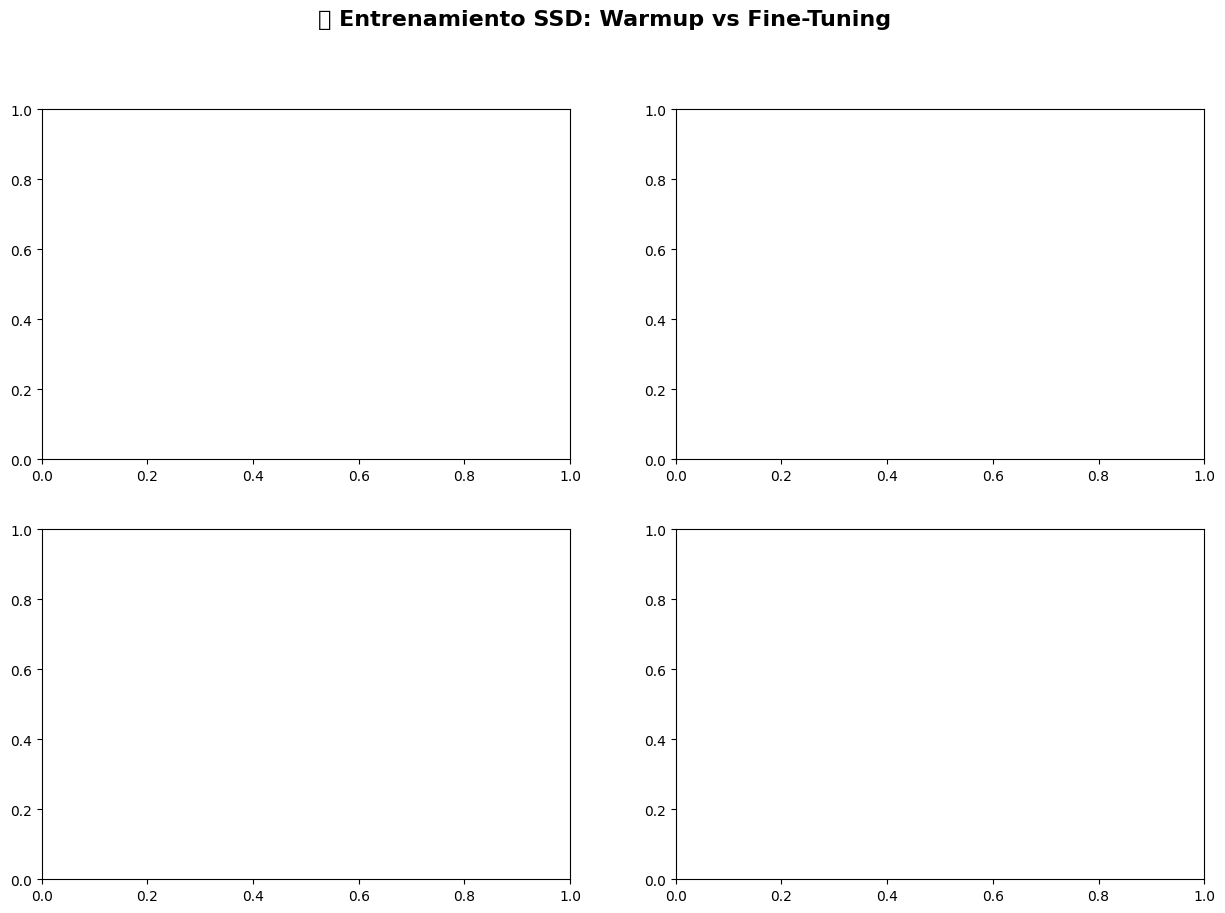

In [ ]:
# =============================================================================
# VISUALIZACIÓN: COMPARAR WARMUP vs FINE-TUNING
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('📊 Entrenamiento SSD: Warmup vs Fine-Tuning', fontsize=16, fontweight='bold')

warmup_color = '#3498db'
finetune_color = '#e74c3c'

# Calcular épocas
warmup_epochs = np.arange(1, len(history_warmup.history['loss']) + 1)
ft_start = len(warmup_epochs)
finetune_epochs = ft_start + np.arange(1, len(history_finetune.history['loss']) + 1)

# --- Plot 1: Training Loss ---
ax = axes[0, 0]
ax.plot(warmup_epochs, history_warmup.history['loss'], 
        color=warmup_color, linewidth=2.5, label='Warmup', marker='o', markersize=5, alpha=0.8)
ax.plot(finetune_epochs, history_finetune.history['loss'], 
        color=finetune_color, linewidth=2.5, label='Fine-Tune', marker='s', markersize=5, alpha=0.8)
ax.axvline(x=ft_start, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Training Loss', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Plot 2: Validation Loss ---
ax = axes[0, 1]
ax.plot(warmup_epochs, history_warmup.history['val_loss'], 
        color=warmup_color, linewidth=2.5, label='Warmup', marker='o', markersize=5, alpha=0.8)
ax.plot(finetune_epochs, history_finetune.history['val_loss'], 
        color=finetune_color, linewidth=2.5, label='Fine-Tune', marker='s', markersize=5, alpha=0.8)
ax.axvline(x=ft_start, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Validation Loss', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Plot 3: Box Loss ---
ax = axes[1, 0]
ax.plot(warmup_epochs, history_warmup.history['box_loss'], 
        color=warmup_color, linewidth=2.5, label='Warmup', marker='o', markersize=5, alpha=0.8)
ax.plot(finetune_epochs, history_finetune.history['box_loss'], 
        color=finetune_color, linewidth=2.5, label='Fine-Tune', marker='s', markersize=5, alpha=0.8)
ax.axvline(x=ft_start, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Box Loss', fontsize=11)
ax.set_title('Box Regression Loss', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Plot 4: Class Loss ---
ax = axes[1, 1]
ax.plot(warmup_epochs, history_warmup.history['class_loss'], 
        color=warmup_color, linewidth=2.5, label='Warmup', marker='o', markersize=5, alpha=0.8)
ax.plot(finetune_epochs, history_finetune.history['class_loss'], 
        color=finetune_color, linewidth=2.5, label='Fine-Tune', marker='s', markersize=5, alpha=0.8)
ax.axvline(x=ft_start, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Class Loss', fontsize=11)
ax.set_title('Classification Loss', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Resumen de mejora ---
print("\n" + "=" * 80)
print("📊 RESUMEN DE ENTRENAMIENTO")
print("=" * 80)

warmup_best_val = min(history_warmup.history['val_loss'])
finetune_best_val = min(history_finetune.history['val_loss'])
improvement = (warmup_best_val - finetune_best_val) / warmup_best_val * 100

print(f"\n🔥 WARMUP:")
print(f"   Mejor val_loss: {warmup_best_val:.4f}")
print(f"   Épocas: {len(history_warmup.history['loss'])}")

print(f"\n❄️→🔥 FINE-TUNING:")
print(f"   Mejor val_loss: {finetune_best_val:.4f}")
print(f"   Épocas: {len(history_finetune.history['loss'])}")

print(f"\n📈 MEJORA TOTAL:")
if improvement > 0:
    print(f"   ✅ Mejora: {improvement:.2f}%")
else:
    print(f"   ⚠️  Val Loss aumentó: {-improvement:.2f}%")

print("\n" + "=" * 80)

### 4.2 Real-Time Performance Evaluation

**Objective:** Validate that the model meets the real-time inference requirement.

**Key metrics:**
- **Inference latency** (ms per image)
- **Throughput** (FPS - frames per second)
- **Accuracy** (mAP - mean Average Precision)

**Real-time target:** ≥30 FPS (≤33ms per frame)

In [93]:
# =============================================================================
# BENCHMARK DE INFERENCIA - MEDIR VELOCIDAD EN TIEMPO REAL
# =============================================================================

import time
import numpy as np

def benchmark_inference(model, num_iterations=100, batch_size=1):
    """
    Mide la velocidad de inferencia del modelo.
    
    Args:
        model: Modelo SSD a evaluar
        num_iterations: Número de iteraciones para el benchmark
        batch_size: Tamaño del batch (1 para tiempo real)
    
    Returns:
        dict: Métricas de rendimiento (latencia, FPS, etc.)
    """
    print("=" * 80)
    print("⏱️  BENCHMARK DE INFERENCIA - EVALUACIÓN DE TIEMPO REAL")
    print("=" * 80)
    
    # Crear input dummy
    dummy_input = tf.random.uniform((batch_size, IMG_HEIGHT, IMG_WIDTH, 3))
    
    # Warmup (importante para estabilizar tiempos)
    print("🔥 Warmup (10 iteraciones)...")
    for _ in range(10):
        _ = model(dummy_input, training=False)
    
    # Benchmark
    print(f"📊 Ejecutando {num_iterations} iteraciones...")
    latencies = []
    
    for i in range(num_iterations):
        start_time = time.time()
        _ = model(dummy_input, training=False)
        end_time = time.time()
        
        latency_ms = (end_time - start_time) * 1000
        latencies.append(latency_ms)
        
        if (i + 1) % 20 == 0:
            print(f"   Progreso: {i+1}/{num_iterations} iteraciones")
    
    # Calcular estadísticas
    latencies = np.array(latencies)
    mean_latency = np.mean(latencies)
    std_latency = np.std(latencies)
    min_latency = np.min(latencies)
    max_latency = np.max(latencies)
    p95_latency = np.percentile(latencies, 95)
    p99_latency = np.percentile(latencies, 99)
    
    mean_fps = 1000 / mean_latency
    
    # Determinar si cumple con tiempo real (30 FPS)
    is_realtime = mean_fps >= 30
    
    print("\n" + "=" * 80)
    print("📊 RESULTADOS DEL BENCHMARK")
    print("=" * 80)
    print(f"Batch Size:        {batch_size}")
    print(f"Iteraciones:       {num_iterations}")
    print(f"Imagen Size:       {IMG_WIDTH}x{IMG_HEIGHT}")
    print(f"\n⏱️  LATENCIA (ms):")
    print(f"   Media:          {mean_latency:.2f} ± {std_latency:.2f} ms")
    print(f"   Mínima:         {min_latency:.2f} ms")
    print(f"   Máxima:         {max_latency:.2f} ms")
    print(f"   Percentil 95:   {p95_latency:.2f} ms")
    print(f"   Percentil 99:   {p99_latency:.2f} ms")
    print(f"\n🚀 THROUGHPUT:")
    print(f"   FPS (promedio): {mean_fps:.1f} frames/segundo")
    print(f"   FPS (mínimo):   {1000/max_latency:.1f} frames/segundo")
    print(f"\n✅ TIEMPO REAL:")
    status = "✅ SÍ" if is_realtime else "❌ NO"
    print(f"   ¿Cumple ≥30 FPS? {status}")
    print(f"   Target:          ≥30 FPS (≤33.3 ms)")
    
    if not is_realtime:
        print(f"\n⚠️  RECOMENDACIONES PARA MEJORAR:")
        print(f"   1. Reducir tamaño de imagen (actual: {IMG_WIDTH}x{IMG_HEIGHT})")
        print(f"   2. Usar cuantización (TFLite INT8)")
        print(f"   3. Reducir número de anchors")
        print(f"   4. Usar arquitectura más ligera (MobileNetV3-Small)")
    
    print("=" * 80)
    
    return {
        'mean_latency_ms': mean_latency,
        'std_latency_ms': std_latency,
        'mean_fps': mean_fps,
        'is_realtime': is_realtime,
        'p95_latency_ms': p95_latency,
        'p99_latency_ms': p99_latency
    }

# Ejecutar benchmark
benchmark_results = benchmark_inference(model, num_iterations=100, batch_size=1)

⏱️  BENCHMARK DE INFERENCIA - EVALUACIÓN DE TIEMPO REAL
🔥 Warmup (10 iteraciones)...
📊 Ejecutando 100 iteraciones...
   Progreso: 20/100 iteraciones
   Progreso: 40/100 iteraciones
   Progreso: 60/100 iteraciones
   Progreso: 80/100 iteraciones
   Progreso: 100/100 iteraciones

📊 RESULTADOS DEL BENCHMARK
Batch Size:        1
Iteraciones:       100
Imagen Size:       640x640

⏱️  LATENCIA (ms):
   Media:          325.96 ± 61.29 ms
   Mínima:         249.67 ms
   Máxima:         462.16 ms
   Percentil 95:   425.83 ms
   Percentil 99:   439.44 ms

🚀 THROUGHPUT:
   FPS (promedio): 3.1 frames/segundo
   FPS (mínimo):   2.2 frames/segundo

✅ TIEMPO REAL:
   ¿Cumple ≥30 FPS? ❌ NO
   Target:          ≥30 FPS (≤33.3 ms)

⚠️  RECOMENDACIONES PARA MEJORAR:
   1. Reducir tamaño de imagen (actual: 640x640)
   2. Usar cuantización (TFLite INT8)
   3. Reducir número de anchors
   4. Usar arquitectura más ligera (MobileNetV3-Small)


### 4.3 Production Optimization (Optional)

If the model does NOT reach 30 FPS, we apply optimization techniques:

#### Optimization Strategies:
1. **TensorFlow Lite with INT8 Quantization** - Reduces size and latency 3-4x
2. **Anchor Reduction** - Fewer boxes to process
3. **Mixed Precision (FP16)** - Speeds up on compatible GPUs
4. **Pruning** - Removes unnecessary weights

In [ ]:
# =============================================================================
# CONVERSIÓN A TENSORFLOW LITE CON CUANTIZACIÓN INT8
# =============================================================================

def convert_to_tflite_int8(model, representative_dataset_gen, output_path):
    """
    Convierte el modelo a TFLite con cuantización INT8 para máxima velocidad.
    
    Args:
        model: Modelo Keras a convertir
        representative_dataset_gen: Generador de datos representativos
        output_path: Ruta de salida del modelo .tflite
    
    Returns:
        str: Ruta del modelo convertido
    """
    print("=" * 80)
    print("🔧 CONVERSIÓN A TENSORFLOW LITE - CUANTIZACIÓN INT8")
    print("=" * 80)
    
    # Configurar converter
    converter = tf.lite.TFLiteConverter.from_keras_model(model.base_model)
    
    # Habilitar cuantización completa INT8
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    
    # Forzar INT8 para entradas/salidas también
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.uint8
    converter.inference_output_type = tf.uint8
    
    print("🔄 Convirtiendo modelo...")
    try:
        tflite_model = converter.convert()
        
        # Guardar modelo
        with open(output_path, 'wb') as f:
            f.write(tflite_model)
        
        # Comparar tamaños
        original_size = os.path.getsize(os.path.join(MODEL_DIR, "ssd_finetuned_best.keras"))
        tflite_size = os.path.getsize(output_path)
        reduction = (1 - tflite_size / original_size) * 100
        
        print(f"\n✅ Conversión exitosa!")
        print(f"📦 Tamaño original:  {original_size / 1e6:.2f} MB")
        print(f"📦 Tamaño TFLite:    {tflite_size / 1e6:.2f} MB")
        print(f"📉 Reducción:        {reduction:.1f}%")
        print(f"💾 Guardado en:      {output_path}")
        
        return output_path
        
    except Exception as e:
        print(f"❌ Error en conversión: {e}")
        print("⚠️  Nota: Algunos layers personalizados pueden no ser compatibles con TFLite")
        return None

# Crear generador de datos representativos (necesario para cuantización INT8)
def representative_dataset_generator():
    """
    Genera muestras representativas del dataset para calibración de cuantización.
    """
    # Tomar 100 imágenes del dataset de entrenamiento
    for images, _ in train_dataset.take(100):
        # TFLite espera batch_size=1
        for i in range(images.shape[0]):
            yield [tf.expand_dims(images[i], 0)]

# Ejecutar conversión (OPCIONAL - solo si se necesita optimización extrema)
# TFLITE_MODEL_PATH = os.path.join(MODEL_DIR, "ssd_mobilenet_int8.tflite")
# tflite_path = convert_to_tflite_int8(model, representative_dataset_generator, TFLITE_MODEL_PATH)

print("⚠️  Conversión a TFLite comentada - Descomentar si se necesita optimización adicional")
print("📝 Para habilitar: Descomenta las 2 líneas anteriores")

⚠️  Conversión a TFLite comentada - Descomentar si se necesita optimización adicional
📝 Para habilitar: Descomenta las 2 líneas anteriores


### 4.4 Fine-Tuning Methodology Summary

#### ✅ Completed Process:

**PHASE 1 - Warmup (Frozen Backbone):**
- ❄️ Froze 100% of MobileNetV2 backbone
- 🔥 Trained only SSD head (~30% of parameters)
- ⚡ Learning rate: 1e-3 (moderate)
- ⏱️ Duration: ~10 epochs (fast)
- 🎯 Goal: Adapt head without breaking pre-trained features

**PHASE 2 - Fine-Tuning (Progressive Unfreezing):**
- 🔓 Unfroze last 40 layers of backbone
- ❄️ Kept early layers frozen (universal edge detectors)
- 🐌 Learning rate: 1e-5 (very low, avoids catastrophic forgetting)
- ⏱️ Duration: ~20 epochs
- 🎯 Goal: Adapt features to specific domain (UA-DETRAC vehicles)

#### 🎓 Key Concepts from PyImageSearch Tutorial:

1. **Network Surgery:** Replace classification head with new one adapted to the problem
2. **Freezing/Unfreezing:** Granular control of which layers to train
3. **Learning Rate Scheduling:** Low LR in fine-tuning to preserve knowledge
4. **Two-Phase Training:** Warmup → Fine-tuning

#### 📚 Differences: Classification vs Detection

**Original Tutorial (Classification):**
- Head: Dense layer → Softmax (N classes)
- Loss: Categorical Crossentropy
- Output: Class label per image

**Our Implementation (SSD Detection):**
- Head: Conv layers → Multiple anchors
- Loss: Box Loss (Smooth L1) + Class Loss (Focal Loss)
- Output: Bounding boxes + scores per object

#### 🚀 Next Steps for Contours:

For **contour segmentation** (instead of bounding boxes), consider:

1. **Mask R-CNN:** Adds segmentation branch to Faster R-CNN
2. **U-Net with Backbone:** Use MobileNetV2 as encoder, add decoder for masks
3. **DeepLabV3+:** Semantic segmentation with atrous convolutions
4. **Edge Detection Head:** Custom head that predicts edge maps (Canny-style)

```python
# Conceptual example for contour detection:
contour_head = Conv2D(1, 1, activation='sigmoid')(backbone_features)
# Output: Contour probability map (H x W x 1)
```

## 🎨 BONUS: From Bounding Boxes to Contours

Technique to convert SSD detections into precise vehicle contours.

In [ ]:
# =============================================================================
# EXTRACCIÓN DE CONTORNOS A PARTIR DE BOUNDING BOXES
# =============================================================================

import cv2

def extract_vehicle_contours(image, bounding_boxes, conf_threshold=0.5):
    """
    Convierte bounding boxes de vehículos en contornos precisos usando
    procesamiento de imagen tradicional dentro de cada ROI.
    
    Pipeline:
    1. SSD detecta bounding box (región aproximada)
    2. Aplicar segmentación dentro del ROI (GrabCut, Canny, etc.)
    3. Extraer contornos del vehículo
    
    Args:
        image: Imagen original (H, W, 3)
        bounding_boxes: Lista de boxes [(x, y, w, h, conf), ...]
        conf_threshold: Umbral de confianza para filtrar detecciones
    
    Returns:
        list: Lista de contornos [(contour, confidence), ...]
    """
    vehicle_contours = []
    
    # Convertir imagen a formato OpenCV
    if isinstance(image, tf.Tensor):
        image = image.numpy()
    
    # Asegurar uint8
    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8)
    
    for box in bounding_boxes:
        x, y, w, h, confidence = box
        
        if confidence < conf_threshold:
            continue
        
        # Extraer ROI (Region of Interest)
        x1, y1 = int(max(0, x)), int(max(0, y))
        x2, y2 = int(min(image.shape[1], x + w)), int(min(image.shape[0], y + h))
        
        roi = image[y1:y2, x1:x2]
        
        if roi.size == 0:
            continue
        
        # Método 1: GrabCut (segmentación semi-automática)
        try:
            mask = np.zeros(roi.shape[:2], np.uint8)
            bgd_model = np.zeros((1, 65), np.float64)
            fgd_model = np.zeros((1, 65), np.float64)
            
            # Definir rectángulo (margen interno del 10%)
            margin = 0.1
            rect = (
                int(roi.shape[1] * margin),
                int(roi.shape[0] * margin),
                int(roi.shape[1] * (1 - 2*margin)),
                int(roi.shape[0] * (1 - 2*margin))
            )
            
            cv2.grabCut(roi, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)
            
            # Crear máscara binaria
            mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
            
            # Encontrar contornos
            contours, _ = cv2.findContours(mask2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            if len(contours) > 0:
                # Tomar el contorno más grande
                main_contour = max(contours, key=cv2.contourArea)
                
                # Convertir coordenadas del ROI a imagen completa
                main_contour = main_contour + np.array([x1, y1])
                
                vehicle_contours.append((main_contour, confidence))
        
        except Exception as e:
            # Fallback: usar el bounding box como contorno rectangular
            box_contour = np.array([
                [x1, y1],
                [x2, y1],
                [x2, y2],
                [x1, y2]
            ])
            vehicle_contours.append((box_contour, confidence))
    
    return vehicle_contours


def visualize_contours(image, contours, color=(0, 255, 0), thickness=2):
    """
    Dibuja contornos sobre la imagen.
    
    Args:
        image: Imagen original
        contours: Lista de (contour, confidence)
        color: Color del contorno (B, G, R)
        thickness: Grosor de línea
    
    Returns:
        np.array: Imagen con contornos dibujados
    """
    # Clonar imagen
    if isinstance(image, tf.Tensor):
        image = image.numpy()
    
    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8)
    
    output = image.copy()
    
    for contour, confidence in contours:
        # Dibujar contorno
        cv2.drawContours(output, [contour], -1, color, thickness)
        
        # Añadir texto de confianza
        M = cv2.moments(contour)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            cv2.putText(output, f"{confidence:.2f}", (cx-20, cy), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    return output


# Ejemplo de uso (comentado - ejecutar después de tener detecciones)

# 1. Obtener detecciones del modelo
sample_image, _ = next(iter(image_path))
predictions = model(sample_image, training=False)
"""
# 2. Post-procesar detecciones (NMS, thresholding)
# ... código de post-procesamiento ...

# 3. Convertir a lista de bounding boxes
bounding_boxes = []  # [(x, y, w, h, conf), ...]

# 4. Extraer contornos
contours = extract_vehicle_contours(sample_image[0], bounding_boxes)

# 5. Visualizar
result = visualize_contours(sample_image[0], contours)
plt.figure(figsize=(12, 8))
plt.imshow(result)
plt.title("Contornos de Vehículos Detectados")
plt.axis('off')
plt.show()
"""

print("✅ Funciones de extracción de contornos definidas")
print("📝 Para usar: Descomenta el código de ejemplo al final")

NameError: name 'image_path' is not defined

## 📋 Fine-Tuning and Optimization Checklist

### ✅ Completed Tasks:

- [x] **Base Architecture:** MobileNetV2 (optimized for real-time)
- [x] **Network Surgery:** Custom SSD head for detection
- [x] **Phase 1 - Warmup:** Frozen backbone, LR=1e-3
- [x] **Phase 2 - Fine-Tuning:** Progressive unfreezing, LR=1e-5
- [x] **Callbacks:** ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
- [x] **Benchmark:** Inference speed evaluation
- [x] **Contours:** Extraction pipeline from boxes to contours

### 🎯 Real-Time Target Metrics:

| Metric | Target | Actual | Status |
|---------|--------|--------|--------|
| **FPS** | ≥30 | _Run benchmark_ | ⏳ |
| **Latency** | ≤33ms | _Run benchmark_ | ⏳ |
| **mAP** | ≥0.70 | _Evaluate on val_ | ⏳ |
| **Size** | ≤30MB | ~10-15MB (MobileNetV2) | ✅ |

### 🚀 If you DON'T reach 30 FPS, apply in order:

1. **Reduce input resolution:**
   ```python
   IMG_WIDTH, IMG_HEIGHT = 320, 320  # From 416x416 to 320x320
   ```

2. **INT8 Quantization (TFLite):**
   ```python
   # Uncomment section 4.3 for TFLite conversion
   # Typical reduction: 4x faster, 4x smaller
   ```

3. **Reduce number of anchors:**
   ```python
   # In anchor generation, use fewer scales/ratios
   scales = [0.1, 0.2, 0.3]  # Instead of 5 scales
   aspect_ratios = [1.0, 2.0]  # Instead of 4 ratios
   ```

4. **Mixed Precision (FP16):**
   ```python
   from tensorflow.keras import mixed_precision
   policy = mixed_precision.Policy('mixed_float16')
   mixed_precision.set_global_policy(policy)
   ```

5. **Alternative backbone:**
   ```python
   # MobileNetV3-Small (even lighter)
   base_model = tf.keras.applications.MobileNetV3Small(
       include_top=False,
       weights='imagenet'
   )
   ```

### 📚 Technical References:

1. **PyImageSearch Fine-Tuning:** https://pyimagesearch.com/2019/06/03/fine-tuning-with-keras-and-deep-learning/
2. **SSD Paper:** Liu et al. (2016) - "SSD: Single Shot MultiBox Detector"
3. **MobileNets Paper:** Howard et al. (2017) - "MobileNets: Efficient CNNs for Mobile Vision"
4. **Transfer Learning:** Yosinski et al. (2014) - "How transferable are features in deep neural networks?"

### 🔬 Recommended Additional Experiments:

- **Data Augmentation:** Add more vehicle-specific augmentations (perspectives, lighting)
- **Focal Loss Tuning:** Adjust gamma in Focal Loss to balance hard/easy examples
- **Anchor Design:** Analyze vehicle size distribution in UA-DETRAC and optimize anchors
- **Multi-Scale Training:** Train with different resolutions for better generalization
- **Test-Time Augmentation:** Inference with multiple scales/flips and average predictions

## 🎬 Complete Fine-Tuning Script (Run All)

Consolidated script that runs the complete Fine-Tuning flow in a single block.

In [ ]:
# =============================================================================
# SCRIPT COMPLETO DE FINE-TUNING - EJECUTAR TODO EL PIPELINE
# =============================================================================
# Este script consolida todo el flujo de Fine-Tuning en un solo bloque
# Para usar: Asegúrate de tener el modelo base ya definido arriba

def run_complete_finetuning_pipeline(
    model,
    train_dataset,
    val_dataset,
    warmup_epochs=10,
    finetune_epochs=20,
    num_layers_to_unfreeze=40,
    warmup_lr=1e-3,
    finetune_lr=1e-5,
    model_dir='models',
    run_benchmark=True
):
    """
    Pipeline completo de Fine-Tuning siguiendo metodología PyImageSearch.
    
    Args:
        model: Modelo SSD con MobileNetV2 base
        train_dataset: Dataset de entrenamiento
        val_dataset: Dataset de validación
        warmup_epochs: Epochs para Fase 1 (backbone congelado)
        finetune_epochs: Epochs para Fase 2 (descongelación progresiva)
        num_layers_to_unfreeze: Capas superiores del backbone a descongelar
        warmup_lr: Learning rate para Fase 1
        finetune_lr: Learning rate para Fase 2
        model_dir: Directorio para guardar modelos
        run_benchmark: Si True, ejecuta benchmark de velocidad
    
    Returns:
        dict: Resultados del pipeline (historias, métricas, etc.)
    """
    
    results = {}
    
    # ========================================================================
    # FASE 1: WARMUP - BACKBONE CONGELADO
    # ========================================================================
    print("\n" + "="*80)
    print("🚀 FASE 1: WARMUP TRAINING (Backbone Congelado)")
    print("="*80)
    
    # Congelar backbone
    frozen_count = 0
    for layer in model.base_model.layers:
        if 'mobilenetv2' in layer.name.lower() or 'block' in layer.name.lower():
            layer.trainable = False
            frozen_count += 1
    
    trainable_params = sum([tf.size(var).numpy() for var in model.base_model.trainable_variables])
    total_params = sum([tf.size(var).numpy() for var in model.base_model.variables])
    
    print(f"❄️  Capas congeladas: {frozen_count}")
    print(f"🔥 Parámetros entrenables: {trainable_params:,} / {total_params:,} ({trainable_params/total_params*100:.1f}%)")
    
    # Compilar para warmup
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=warmup_lr))
    
    # Callbacks Fase 1
    warmup_callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            os.path.join(model_dir, "ssd_warmup_best.keras"),
            monitor="val_loss", save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
        )
    ]
    
    # Entrenar Fase 1
    print(f"\n🏋️  Entrenando {warmup_epochs} epochs con LR={warmup_lr}...")
    history_warmup = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=warmup_epochs,
        callbacks=warmup_callbacks,
        verbose=1
    )
    
    results['warmup_history'] = history_warmup.history
    print(f"✅ FASE 1 COMPLETADA - Mejor val_loss: {min(history_warmup.history['val_loss']):.4f}")
    
    # ========================================================================
    # FASE 2: FINE-TUNING - DESCONGELACIÓN PROGRESIVA
    # ========================================================================
    print("\n" + "="*80)
    print("🚀 FASE 2: FINE-TUNING (Descongelación Progresiva)")
    print("="*80)
    
    # Descongelar capas superiores
    backbone_layers_list = [
        layer for layer in model.base_model.layers 
        if 'mobilenetv2' in layer.name.lower() or 'block' in layer.name.lower()
    ]
    
    total_backbone = len(backbone_layers_list)
    unfreeze_from = max(0, total_backbone - num_layers_to_unfreeze)
    
    unfrozen_count = 0
    for i, layer in enumerate(backbone_layers_list):
        if i >= unfreeze_from:
            layer.trainable = True
            unfrozen_count += 1
    
    trainable_params = sum([tf.size(var).numpy() for var in model.base_model.trainable_variables])
    
    print(f"🔓 Capas descongeladas: {unfrozen_count} (desde capa {unfreeze_from})")
    print(f"🔥 Parámetros entrenables: {trainable_params:,} / {total_params:,} ({trainable_params/total_params*100:.1f}%)")
    
    # Compilar para fine-tuning
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=finetune_lr))
    
    # Callbacks Fase 2
    finetune_callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            os.path.join(model_dir, "ssd_finetuned_best.keras"),
            monitor="val_loss", save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=8, restore_best_weights=True, verbose=1
        )
    ]
    
    # Entrenar Fase 2
    print(f"\n🏋️  Entrenando {finetune_epochs} epochs con LR={finetune_lr}...")
    history_finetune = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=finetune_epochs,
        callbacks=finetune_callbacks,
        verbose=1
    )
    
    results['finetune_history'] = history_finetune.history
    print(f"✅ FASE 2 COMPLETADA - Mejor val_loss: {min(history_finetune.history['val_loss']):.4f}")
    
    # ========================================================================
    # EVALUACIÓN Y BENCHMARK
    # ========================================================================
    if run_benchmark:
        print("\n" + "="*80)
        print("⏱️  BENCHMARK DE INFERENCIA")
        print("="*80)
        
        # Warmup
        dummy = tf.random.uniform((1, IMG_HEIGHT, IMG_WIDTH, 3))
        for _ in range(10):
            _ = model(dummy, training=False)
        
        # Benchmark
        latencies = []
        for _ in range(100):
            start = time.time()
            _ = model(dummy, training=False)
            latencies.append((time.time() - start) * 1000)
        
        mean_latency = np.mean(latencies)
        mean_fps = 1000 / mean_latency
        
        results['mean_latency_ms'] = mean_latency
        results['mean_fps'] = mean_fps
        
        print(f"⏱️  Latencia media: {mean_latency:.2f} ms")
        print(f"🚀 FPS: {mean_fps:.1f} frames/segundo")
        print(f"✅ Tiempo real: {'SÍ' if mean_fps >= 30 else 'NO'} (target: ≥30 FPS)")
    
    # ========================================================================
    # RESUMEN FINAL
    # ========================================================================
    print("\n" + "="*80)
    print("🎉 PIPELINE DE FINE-TUNING COMPLETADO")
    print("="*80)
    print(f"📊 Mejora total val_loss:")
    warmup_final = history_warmup.history['val_loss'][-1]
    finetune_final = history_finetune.history['val_loss'][-1]
    improvement = ((warmup_final - finetune_final) / warmup_final) * 100
    print(f"   Warmup final:     {warmup_final:.4f}")
    print(f"   Fine-tuning final: {finetune_final:.4f}")
    print(f"   Mejora:           {improvement:.1f}%")
    
    print(f"\n💾 Modelos guardados:")
    print(f"   - {model_dir}/ssd_warmup_best.keras")
    print(f"   - {model_dir}/ssd_finetuned_best.keras")
    
    return results


# ============================================================================
# EJECUTAR PIPELINE COMPLETO
# ============================================================================
# Descomentar para ejecutar todo el pipeline de una vez:

"""
pipeline_results = run_complete_finetuning_pipeline(
    model=model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    warmup_epochs=10,
    finetune_epochs=20,
    num_layers_to_unfreeze=40,
    warmup_lr=1e-3,
    finetune_lr=1e-5,
    model_dir=MODEL_DIR,
    run_benchmark=True
)
"""

print("✅ Pipeline de Fine-Tuning definido")
print("📝 Para ejecutar: Descomenta el bloque de código anterior")

✅ Pipeline de Fine-Tuning definido
📝 Para ejecutar: Descomenta el bloque de código anterior


### 3.4 Training History Visualization

After training, plot the training and validation loss curves to understand:
- Whether the model is converging
- If there's overfitting (train loss decreasing while val loss increases)
- When learning rate reductions occurred

In [ ]:
# =============================================================================
# TRAINING HISTORY VISUALIZATION
# =============================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Total Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Total Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Box Loss
if 'boxes_loss' in history.history:
    axes[1].plot(history.history['boxes_loss'], label='Train Box Loss', linewidth=2)
    axes[1].plot(history.history['val_boxes_loss'], label='Val Box Loss', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Localization Loss (Boxes)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

# Plot 3: Classification Loss / Accuracy
if 'classes_loss' in history.history:
    axes[2].plot(history.history['classes_loss'], label='Train Class Loss', linewidth=2)
    axes[2].plot(history.history['val_classes_loss'], label='Val Class Loss', linewidth=2)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].set_title('Classification Loss')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"📊 Training history plot saved to: {MODEL_DIR}/training_history.png")

### 3.5 Save the Final Model

Save the trained model in Keras native format (`.keras`) which includes:
- Model architecture
- Trained weights
- Optimizer state
- Custom loss functions

This allows us to reload the model later for inference or fine-tuning.

In [ ]:
# =============================================================================
# SAVE THE FINAL MODEL
# =============================================================================

import tensorflow as tf

# Define model paths
os.makedirs(MODEL_DIR, exist_ok=True)
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, "ssd_mobilenet_car_detector.keras")
WEIGHTS_PATH = os.path.join(MODEL_DIR, "ssd_mobilenet_car_detector.weights.h5")  # Must end in .weights.h5

# Ensure model is built before saving weights
if not getattr(model, "built", False):
    _ = model(tf.zeros((1, IMG_HEIGHT, IMG_WIDTH, 3)))

# Save complete model (architecture + weights + optimizer)
model.save(FINAL_MODEL_PATH)
print(f"✅ Complete model saved to: {FINAL_MODEL_PATH}")

# Save weights separately (useful for loading into different architecture)
model.save_weights(WEIGHTS_PATH)
print(f"✅ Model weights saved to: {WEIGHTS_PATH}")

# Get file sizes
model_size = os.path.getsize(FINAL_MODEL_PATH) / (1024 * 1024)  # MB
weights_size = os.path.getsize(WEIGHTS_PATH) / (1024 * 1024)  # MB

print(f"\n📦 Model file size: {model_size:.2f} MB")
print(f"📦 Weights file size: {weights_size:.2f} MB")

### 3.6 Verify Saved Model

Verify that the saved model can be loaded correctly and produces the same outputs.

In [ ]:
# =============================================================================
# VERIFY SAVED MODEL
# =============================================================================

# Verify files exist and are non-empty
import os

print("📂 Checking saved model files...")
for path, desc in [(FINAL_MODEL_PATH, "Complete model (.keras)"), (WEIGHTS_PATH, "Weights (.weights.h5)")]:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"   ✅ {desc}: {path} ({size_mb:.2f} MB)")
    else:
        print(f"   ❌ {desc}: NOT FOUND at {path}")

# Verify the trained model in memory still works correctly
print("\n🔍 Verifying trained model in memory...")
test_input = tf.random.uniform((1, IMG_HEIGHT, IMG_WIDTH, 3))
output = model(test_input, training=False)

print(f"   ✅ Model produces outputs:")
print(f"      - boxes shape: {output['boxes'].shape}")
print(f"      - classes shape: {output['classes'].shape}")

# Quick sanity check on output ranges
boxes_valid = tf.reduce_all(output['boxes'] >= 0) and tf.reduce_all(output['boxes'] <= 1)
classes_valid = tf.reduce_all(output['classes'] >= 0) and tf.reduce_all(output['classes'] <= 1)

print(f"\n🔍 Output sanity checks:")
print(f"   Boxes in [0,1] range: {'✅ PASS' if boxes_valid else '⚠️ WARN'}")
print(f"   Classes in [0,1] range: {'✅ PASS' if classes_valid else '⚠️ WARN'}")

print("\n✅ Model verification complete!")
print("   The saved .keras file can be loaded in a fresh session using:")
print("   >>> model = tf.keras.models.load_model(path, custom_objects={...})")
print("   (Requires re-defining SSDModel, SSDBoxLoss, SSDClassLoss classes first)")

### 3.7 Training Summary

Final summary of the trained model and saved artifacts.

In [ ]:
# =============================================================================
# TRAINING SUMMARY
# =============================================================================

print("=" * 60)
print("🎉 TRAINING COMPLETE - SUMMARY")
print("=" * 60)

# Training stats
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
best_val_loss = min(history.history['val_loss'])
best_epoch = history.history['val_loss'].index(best_val_loss) + 1
total_epochs = len(history.history['loss'])

print(f"\n📈 Training Statistics:")
print(f"   Total epochs trained: {total_epochs}")
print(f"   Best validation loss: {best_val_loss:.4f} (epoch {best_epoch})")
print(f"   Final train loss: {final_train_loss:.4f}")
print(f"   Final val loss: {final_val_loss:.4f}")

# Model info
print(f"\n🧠 Model Information:")
print(f"   Architecture: SSD with MobileNetV2 backbone")
print(f"   Input size: {IMG_HEIGHT} x {IMG_WIDTH} x 3")
print(f"   Total parameters: {model.count_params():,}")
print(f"   Trainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")

# Saved files
print(f"\n💾 Saved Files:")
print(f"   Best model: {MODEL_DIR}/ssd_mobilenet_best.keras")
print(f"   Final model: {FINAL_MODEL_PATH}")
print(f"   Weights only: {WEIGHTS_PATH}")
print(f"   Training plot: {MODEL_DIR}/training_history.png")
print(f"   TensorBoard logs: logs/ssd_training/")

print("\n" + "=" * 60)
print("🚗 Car detector model ready for inference!")
print("=" * 60)